# NHS England — A&E Attendances and Emergency Admissions
## Trend Analysis | Financial Year 2025/26

### Executive Summary
This analysis examines NHS England A&E performance data across the
full 2025/26 financial year from April 2025 to March 2026, covering
12 months of provider level attendance, waiting time and emergency
admission data across all NHS trusts and providers submitting A&E
returns to NHS England. Fifteen analyses were conducted covering
national trends, provider level performance, regional variation,
seasonal pressure and a summary heatmap.

| | |
|---|---|
| **Data source** | NHS England — A&E Attendances and Emergency Admissions |
| **Coverage** | All NHS trusts and providers submitting monthly A&E returns |
| **Period** | April 2025 to March 2026 |
| **Analyst** | Kingsley Eboh |
| **Tools** | Python · pandas · matplotlib · seaborn · PostgreSQL · Power BI |

### Objectives
- Quantify monthly A&E attendance volumes and identify seasonal patterns
- Track 4-hour performance against the NHS England standard across the year
- Measure the scale and trend of patients waiting 12 or more hours before admission
- Identify highest volume providers and those with the greatest performance challenges
- Identify best performing providers and assess performance consistency across the year
- Analyse emergency admission trends across the financial year
- Compare regional attendance volumes and breach rates across NHS England
- Assess ICB level performance variation across the year
- Analyse month on month changes in attendance volumes and breach rates
- Assess the impact of winter pressure from December 2025 to February 2026
- Present findings in a summary performance heatmap across the top 20 providers
- Execute SQL analytical queries against a PostgreSQL database
- Present key findings in an interactive Power BI dashboard

### Key Metrics
| Metric | Definition |
|---|---|
| Type 1 attendances | Major A&E departments — consultant led, 24 hours a day |
| 4-hour breach rate | Percentage of patients waiting over 4 hours in Type 1 departments |
| 12 hour or longer waits | Patients waiting 12 or more hours before being admitted to hospital |
| Emergency admissions | Unplanned hospital admissions via A&E pathways |
| Month on month change | Percentage change in attendance volume and breach rate from prior month |
| Performance consistency | Standard deviation of monthly breach rates across the financial year |

### Section 1: Setup and Configuration
Required libraries were imported and a consistent chart style was
configured for all visualisations produced in this analysis. Chart
settings were standardised across font sizes, grid style and figure
resolution to ensure a consistent professional appearance throughout
the notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Suppress pandas and matplotlib deprecation warnings for clean output
warnings.filterwarnings('ignore')

# Global chart style — applied consistently across all visualisations
sns.set_theme(style='whitegrid', palette='muted')

plt.rcParams.update({
    'figure.dpi': 150,          # High resolution output
    'axes.titlesize': 13,       # Chart title font size
    'axes.labelsize': 11,       # Axis label font size
    'xtick.labelsize': 10,      # X-axis tick label size
    'ytick.labelsize': 10,      # Y-axis tick label size
    'axes.spines.top': False,   # Remove top border
    'axes.spines.right': False, # Remove right border
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Section 2: Data Acquisition
Monthly A&E attendance and emergency admission data was loaded from
12 CSV files published by NHS England covering the full 2025/26
financial year from April 2025 to March 2026. Each file represents
one month of returns from approximately 200 NHS trusts and providers.
Files were combined into a single analytical dataset with chronological
month ordering preserved for consistent chart sequencing.

Data files are excluded from version control. Download the monthly
CSV files from NHS England at:
england.nhs.uk/statistics/statistical-work-areas/ae-waiting-times-and-activity

In [2]:
import os

# Monthly file mapping — NHS England filenames for 2025/26 financial year
FILES = {
    'Apr-25': 'April-2025-CSV-revised.csv',
    'May-25': 'May-2025-CSV-revised.csv',
    'Jun-25': 'June-2025-CSV-revised.csv',
    'Jul-25': 'July-2025-CSV-revised.csv',
    'Aug-25': 'August-2025-CSV-revised.csv',
    'Sep-25': 'September-2025-CSV-revised.csv',
    'Oct-25': 'October-2025-CSV-hg6dl.csv',
    'Nov-25': 'November-2025-CSV-G9pr3.csv',
    'Dec-25': 'December-2025-CSV-K7F4Sp.csv',
    'Jan-26': 'January-2026-CSV-S6H81b.csv',
    'Feb-26': 'February-2026-CSV-Dl8t54.csv',
    'Mar-26': 'March-2026-CSV-G49lw.csv',
}

# Data directory — CSV files excluded from version control
# Download from: england.nhs.uk/statistics/statistical-work-areas/ae-waiting-times-and-activity
DATA_DIR = os.path.expanduser('~/projects/nhs-trend-analysis/data/')

# Load and combine all 12 monthly files
dfs = []
missing_files = []

for label, filename in FILES.items():
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        df = pd.read_csv(path, low_memory=False)
        df['Month'] = label
        dfs.append(df)
        print(f"Loaded: {label} — {filename} ({len(df):,} rows)")
    else:
        missing_files.append(filename)
        print(f"Missing: {filename}")

if missing_files:
    print(f"\nWarning: {len(missing_files)} file(s) not found")
    print("Download missing files from NHS England statistics page")
else:
    # Combine all months into single analytical dataset
    raw = pd.concat(dfs, ignore_index=True)

    # Apply categorical month ordering for correct chart sequencing
    MONTH_ORDER = list(FILES.keys())
    raw['Month'] = pd.Categorical(
        raw['Month'],
        categories=MONTH_ORDER,
        ordered=True
    )

    print(f"\nData load complete")
    print(f"Total records:  {raw.shape[0]:,}")
    print(f"Total columns:  {raw.shape[1]}")
    print(f"Months covered: {raw['Month'].nunique()}")
    print(f"Date range:     {MONTH_ORDER[0]} to {MONTH_ORDER[-1]}")

Loaded: Apr-25 — April-2025-CSV-revised.csv (199 rows)
Loaded: May-25 — May-2025-CSV-revised.csv (201 rows)
Loaded: Jun-25 — June-2025-CSV-revised.csv (202 rows)
Loaded: Jul-25 — July-2025-CSV-revised.csv (202 rows)
Loaded: Aug-25 — August-2025-CSV-revised.csv (202 rows)
Loaded: Sep-25 — September-2025-CSV-revised.csv (202 rows)
Loaded: Oct-25 — October-2025-CSV-hg6dl.csv (197 rows)
Loaded: Nov-25 — November-2025-CSV-G9pr3.csv (198 rows)
Loaded: Dec-25 — December-2025-CSV-K7F4Sp.csv (198 rows)
Loaded: Jan-26 — January-2026-CSV-S6H81b.csv (198 rows)
Loaded: Feb-26 — February-2026-CSV-Dl8t54.csv (198 rows)
Loaded: Mar-26 — March-2026-CSV-G49lw.csv (200 rows)

Data load complete
Total records:  2,397
Total columns:  23
Months covered: 12
Date range:     Apr-25 to Mar-26


### Step 3: Explore the raw data
Prior to cleaning, all 23 columns were inspected for structure, data types, and 
missing values. No missing values were found across any column. Column names were 
identified as lengthy and inconsistent, flagging the need for renaming in the 
cleaning step.

In [3]:

# Preview first 3 rows to confirm structure and column alignment
print("Dataset preview — first 3 rows:")
display(raw.head(3))

# Display all column names for reference
print(f"\nColumn names ({len(raw.columns)} total):")
for i, col in enumerate(raw.columns, 1):
    print(f"  {i:2}. {col}")

# Assess data completeness across all columns
missing = raw.isnull().sum()
missing_pct = (missing / len(raw) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print(f"\nData completeness assessment:")
print(f"Total rows: {len(raw):,}")
print(f"Total columns: {len(raw.columns)}")
print(f"\nMissing values per column:")
print(missing_summary[missing_summary['Missing Count'] > 0].to_string())

if missing_summary['Missing Count'].sum() == 0:
    print("No missing values found across all columns.")

Dataset preview — first 3 rows:


,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions,Month
0,MSitAE-APRIL-2025,NDJ,NHS ENGLAND SOUTH EAST,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,2350,0,0,0,...,0,0,0,0,0,0,0,0,0,Apr-25
1,MSitAE-APRIL-2025,NTV0B,NHS ENGLAND SOUTH EAST,ASHFORD WALK-IN-CENTRE,0,0,2333,0,0,0,...,0,0,0,0,0,0,0,0,0,Apr-25
2,MSitAE-APRIL-2025,NTV0W,NHS ENGLAND SOUTH EAST,WOKING WALK IN CENTRE,0,0,2528,0,0,0,...,0,0,0,0,0,0,0,0,0,Apr-25



Column names (23 total):
   1. Period
   2. Org Code
   3. Parent Org
   4. Org name
   5. A&E attendances Type 1
   6. A&E attendances Type 2
   7. A&E attendances Other A&E Department
   8. A&E attendances Booked Appointments Type 1
   9. A&E attendances Booked Appointments Type 2
  10. A&E attendances Booked Appointments Other Department
  11. Attendances over 4hrs Type 1
  12. Attendances over 4hrs Type 2
  13. Attendances over 4hrs Other Department
  14. Attendances over 4hrs Booked Appointments Type 1
  15. Attendances over 4hrs Booked Appointments Type 2
  16. Attendances over 4hrs Booked Appointments Other Department
  17. Patients who have waited 4-12 hs from DTA to admission
  18. Patients who have waited 12+ hrs from DTA to admission
  19. Emergency admissions via A&E - Type 1
  20. Emergency admissions via A&E - Type 2
  21. Emergency admissions via A&E - Other A&E department
  22. Other emergency admissions
  23. Month

Data completeness assessment:
Total rows: 2,397
Tota

### Section 4: Data Cleaning and Feature Engineering
Column names were standardised and shortened to concise aliases for
analytical efficiency. Numerical columns were converted to consistent
numeric types with zero filling applied where values were absent.
Region names were stripped of whitespace inconsistencies. Three
derived columns were calculated to support downstream analysis:
total attendances combining all department types, total 4-hour
breaches combining all department types and total emergency admissions
across all admission routes. A 4-hour breach rate was calculated for
Type 1 departments only, consistent with NHS England reporting
methodology. Summary and total rows were removed to ensure only
individual provider level records were retained for analysis.

In [4]:
# Remove leading and trailing whitespace from column names
raw.columns = raw.columns.str.strip()

# Rename verbose NHS column names to concise analytical aliases
raw.rename(columns={
    'A&E attendances Type 1':                                 'att_t1',
    'A&E attendances Type 2':                                 'att_t2',
    'A&E attendances Other A&E Department':                   'att_other',
    'Attendances over 4hrs Type 1':                           'over4_t1',
    'Attendances over 4hrs Type 2':                           'over4_t2',
    'Attendances over 4hrs Other Department':                 'over4_other',
    'Patients who have waited 4-12 hs from DTA to admission': 'wait_4_12',
    'Patients who have waited 12+ hrs from DTA to admission': 'wait_12plus',
    'Emergency admissions via A&E - Type 1':                  'emerg_t1',
    'Emergency admissions via A&E - Type 2':                  'emerg_t2',
    'Emergency admissions via A&E - Other A&E department':    'emerg_other',
    'Other emergency admissions':                             'emerg_other2',
    'Org name':                                               'org_name',
    'Parent Org':                                             'region',
}, inplace=True)

# Convert performance columns to numeric — coerce non-numeric values to NaN then fill with 0
num_cols = [
    'att_t1', 'att_t2', 'att_other',
    'over4_t1', 'over4_t2', 'over4_other',
    'wait_4_12', 'wait_12plus',
    'emerg_t1', 'emerg_t2', 'emerg_other', 'emerg_other2'
]
raw[num_cols] = raw[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Standardise region names by removing whitespace inconsistencies
raw['region'] = raw['region'].str.strip()

# Derive combined performance columns across all department types
raw['total_att']   = raw['att_t1'] + raw['att_t2'] + raw['att_other']
raw['total_over4'] = raw['over4_t1'] + raw['over4_t2'] + raw['over4_other']
raw['total_emerg'] = (raw['emerg_t1'] + raw['emerg_t2'] +
                      raw['emerg_other'] + raw['emerg_other2'])

# Calculate Type 1 breach rate — only where Type 1 attendances were recorded
# Type 1 breach rate is the primary NHS performance indicator for A&E departments
raw['breach_rate'] = raw.apply(
    lambda r: round(r['over4_t1'] / r['att_t1'] * 100, 2)
    if r['att_t1'] > 0 else None,
    axis=1
)

# Remove aggregate summary rows — retain individual provider records only
raw = raw[~raw['org_name'].str.upper().str.contains('TOTAL', na=False)]

# Confirm cleaning and feature engineering complete
print("Data cleaning and feature engineering complete.")
print(f"Provider level records retained: {raw.shape[0]:,}")
print(f"Columns in cleaned dataset: {raw.shape[1]}")
print(f"\nDerived columns added:")
print(f"  total_att   — combined attendances across all department types")
print(f"  total_over4 — combined 4-hour breaches across all department types")
print(f"  total_emerg — combined emergency admissions across all routes")
print(f"  breach_rate — Type 1 breach rate as a percentage")
print(f"\nSample of cleaned dataset:")
display(raw[['Month', 'org_name', 'att_t1', 'over4_t1',
             'breach_rate', 'total_emerg']].head(5))

Data cleaning and feature engineering complete.
Provider level records retained: 2,385
Columns in cleaned dataset: 27

Derived columns added:
  total_att   — combined attendances across all department types
  total_over4 — combined 4-hour breaches across all department types
  total_emerg — combined emergency admissions across all routes
  breach_rate — Type 1 breach rate as a percentage

Sample of cleaned dataset:


,Month,org_name,att_t1,over4_t1,breach_rate,total_emerg
0,Apr-25,FIRST COMMUNITY HEALTH AND CARE CIC,0,0,NaN,0
1,Apr-25,ASHFORD WALK-IN-CENTRE,0,0,NaN,0
2,Apr-25,WOKING WALK IN CENTRE,0,0,NaN,0
3,Apr-25,SOUTH BIRMINGHAM GP WALK IN CENTRE,0,0,NaN,0
4,Apr-25,PHL LYMINGTON UTC,0,0,NaN,0


### Section 5: Monthly Aggregation
Individual provider level records were aggregated to monthly national
totals to support trend analysis across the 2025/26 financial year.
Key performance metrics were summed across all providers for each
month including total attendances, Type 1 attendances, 4-hour
breaches, emergency admissions and 12 hour or longer waits before
admission. A national monthly breach rate was calculated as the
proportion of Type 1 attendances exceeding the 4-hour standard.

In [5]:
# Aggregate individual provider records to national monthly totals

monthly = raw.groupby('Month', observed=True).agg(
    total_att   = ('total_att',   'sum'),   # Total attendances all department types
    att_t1      = ('att_t1',      'sum'),   # Type 1 attendances only
    total_over4 = ('total_over4', 'sum'),   # Total 4-hour breaches all department types
    total_emerg = ('total_emerg', 'sum'),   # Total emergency admissions all routes
    wait_12plus = ('wait_12plus', 'sum'),   # Patients waiting 12 or more hours before admission
).reset_index()

# Calculate national monthly breach rate
# Breach rate calculated on Type 1 attendances only — consistent with NHS England methodology
monthly['breach_rate_pct'] = (
    monthly['total_over4'] / monthly['att_t1'] * 100
).round(1)

# Display monthly summary table
print(f"Monthly national summary — 2025/26 financial year ({len(monthly)} months):")
print(f"Breach rate range: {monthly['breach_rate_pct'].min()}% to {monthly['breach_rate_pct'].max()}%")
print(f"Total attendances: {monthly['total_att'].sum():,}")
print(f"Total 12hr+ waits: {monthly['wait_12plus'].sum():,}")
print()
display(monthly)

Monthly national summary — 2025/26 financial year (12 months):
Breach rate range: 37.9% to 44.8%
Total attendances: 26,965,026
Total 12hr+ waits: 570,931



,Month,total_att,att_t1,total_over4,total_emerg,wait_12plus,breach_rate_pct
0,Apr-25,2209687,1354959,571127,528230,44648,42.2
1,May-25,2309298,1419306,581375,545128,42891,41.0
2,Jun-25,2268166,1395330,566734,535941,38683,40.6
3,Jul-25,2320374,1433180,560285,559392,35467,39.1
4,Aug-25,2182723,1351631,539040,526399,35909,39.9
5,Sep-25,2227502,1385429,567723,535580,44765,41.0
6,Oct-25,2314177,1449480,610640,554193,54314,42.1
7,Nov-25,2261926,1418397,595846,531747,50648,42.0
8,Dec-25,2240325,1407880,599421,542195,50775,42.6
9,Jan-26,2235959,1405298,629487,546136,71517,44.8


#### Analysis 1: Monthly A&E Attendance Volume
Total A&E attendance volumes were analysed across all 12 months of
the 2025/26 financial year to identify seasonal patterns and monthly
variation in demand. Attendances across all department types were
combined to produce a national monthly total.

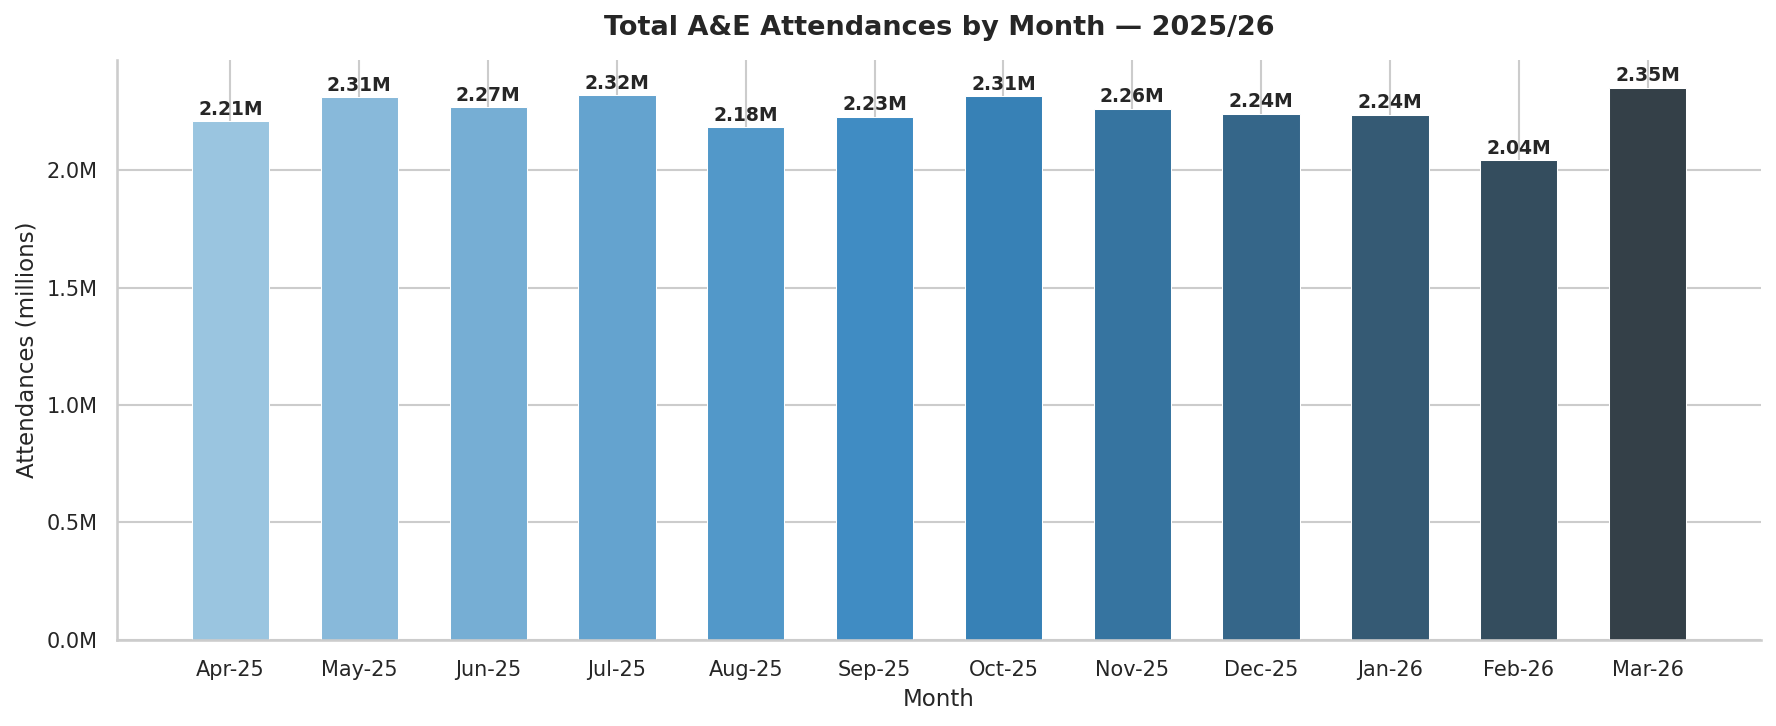

Analysis 1 complete
Busiest month: Mar-26 (2,351,317 attendances)
Quietest month: Feb-26 (2,043,572 attendances)


In [6]:

fig, ax = plt.subplots(figsize=(12, 5))

# Bar chart with graduated blue palette for visual depth
bars = ax.bar(
    monthly['Month'],
    monthly['total_att'] / 1_000_000,
    color=sns.color_palette('Blues_d', len(monthly)),
    width=0.6,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels above each bar
for bar, val in zip(bars, monthly['total_att']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val / 1e6:.2f}M',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

ax.set_title(
    'Total A&E Attendances by Month — 2025/26',
    fontweight='bold', pad=12
)
ax.set_ylabel('Attendances (millions)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}M')
)

plt.tight_layout()
plt.savefig('figures/analysis1_monthly_attendances.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 1 complete")
print(f"Busiest month: {monthly.loc[monthly['total_att'].idxmax(), 'Month']} "
      f"({monthly['total_att'].max():,.0f} attendances)")
print(f"Quietest month: {monthly.loc[monthly['total_att'].idxmin(), 'Month']} "
      f"({monthly['total_att'].min():,.0f} attendances)")

#### Analysis 2: Monthly 4-Hour Breach Rate Trend
The monthly Type 1 4-hour breach rate was tracked across the full
2025/26 financial year and compared against the NHS England target
ceiling of 24%. The breach rate measures the proportion of Type 1
A&E attendances where patients waited more than 4 hours from arrival
to admission, transfer or discharge.

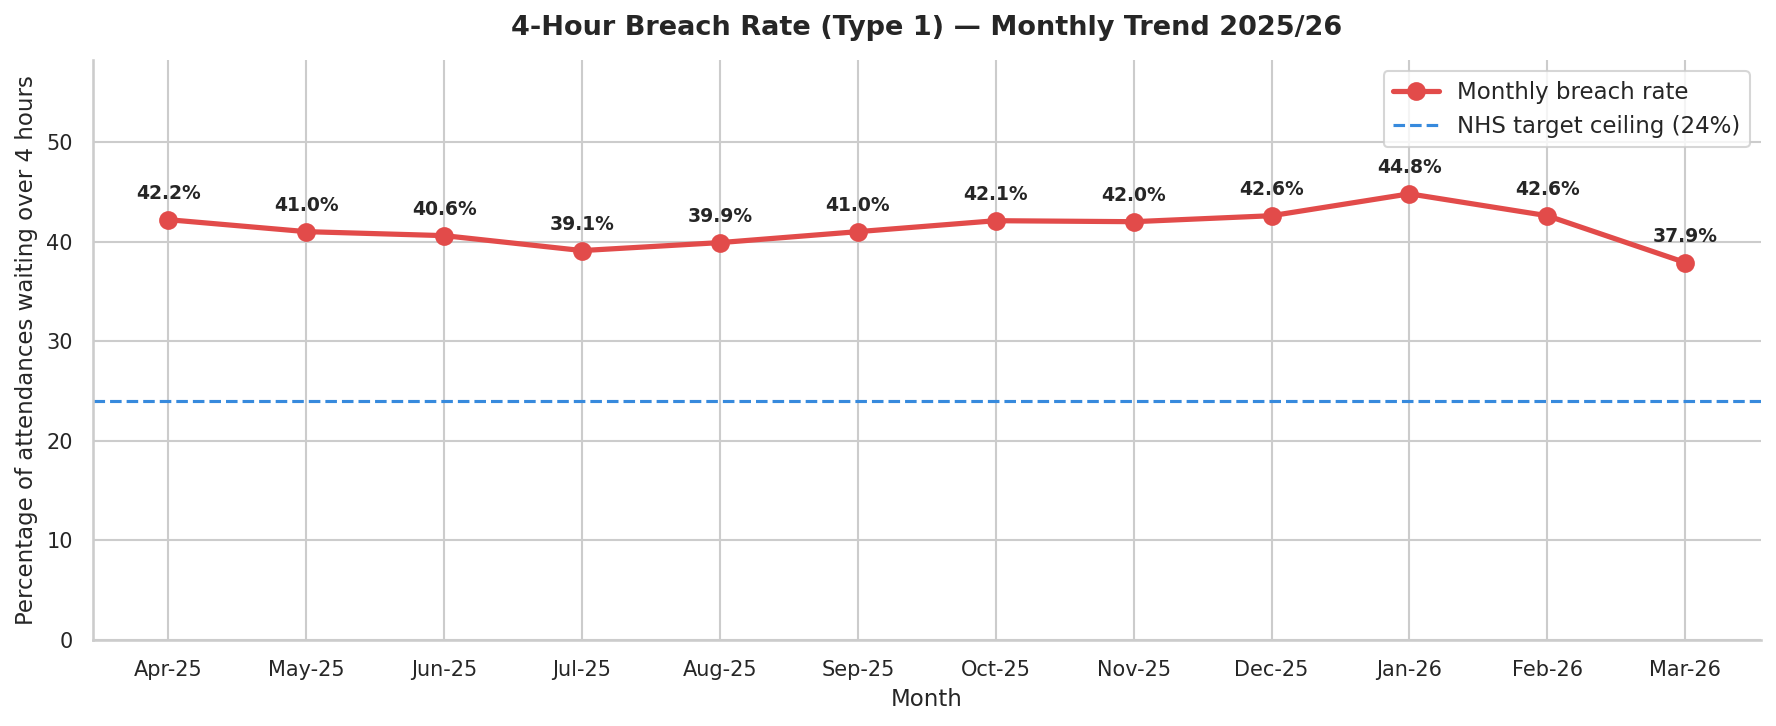

Analysis 2 complete
Highest breach rate: Jan-26 (44.8%)
Lowest breach rate:  Mar-26 (37.9%)
NHS missed the 24% target in all 12 reporting periods


In [7]:
# Analysis 2: Monthly 4-Hour Breach Rate Trend

fig, ax = plt.subplots(figsize=(12, 5))

# Breach rate trend line
ax.plot(
    monthly['Month'],
    monthly['breach_rate_pct'],
    marker='o',
    linewidth=2.5,
    color='#E24B4A',
    markersize=8,
    label='Monthly breach rate'
)

# NHS target ceiling reference line
ax.axhline(
    24,
    color='#378ADD',
    linestyle='--',
    linewidth=1.5,
    label='NHS target ceiling (24%)'
)

# Add data labels above each data point
for month, val in zip(monthly['Month'], monthly['breach_rate_pct']):
    ax.annotate(
        f'{val}%',
        (month, val),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    '4-Hour Breach Rate (Type 1) — Monthly Trend 2025/26',
    fontweight='bold', pad=12
)
ax.set_ylabel('Percentage of attendances waiting over 4 hours')
ax.set_xlabel('Month')
ax.set_ylim(0, monthly['breach_rate_pct'].max() * 1.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/analysis2_4hr_breach_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 2 complete")
print(f"Highest breach rate: {monthly.loc[monthly['breach_rate_pct'].idxmax(), 'Month']} "
      f"({monthly['breach_rate_pct'].max()}%)")
print(f"Lowest breach rate:  {monthly.loc[monthly['breach_rate_pct'].idxmin(), 'Month']} "
      f"({monthly['breach_rate_pct'].min()}%)")
print(f"NHS missed the 24% target in all {len(monthly)} reporting periods")

#### Analysis 3: Monthly 12 Hour or Longer Wait Trend
The monthly volume of patients waiting 12 or more hours before
being admitted to hospital was tracked across the full 2025/26
financial year. This metric is a key indicator of system-wide
bed capacity pressure and patient flow constraints across NHS
England emergency departments.

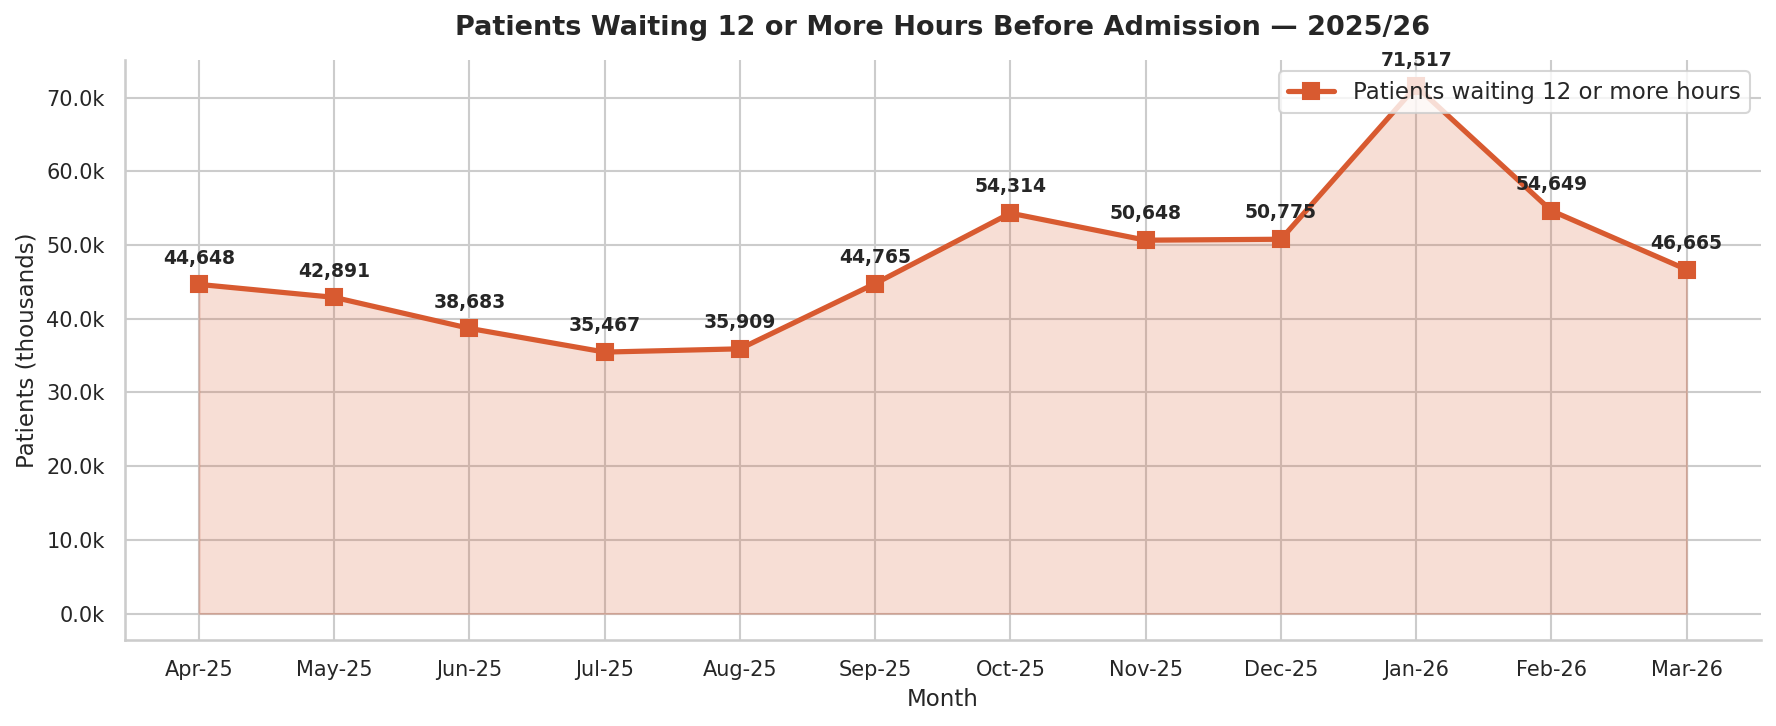

Analysis 3 complete
Highest month: Jan-26 (71,517 patients)
Lowest month:  Jul-25 (35,467 patients)
Total across 2025/26: 570,931 patients


In [8]:

fig, ax = plt.subplots(figsize=(12, 5))

# Shaded area under the trend line for visual impact
ax.fill_between(
    monthly['Month'],
    monthly['wait_12plus'] / 1000,
    alpha=0.2,
    color='#D85A30'
)

# Trend line with markers
ax.plot(
    monthly['Month'],
    monthly['wait_12plus'] / 1000,
    marker='s',
    linewidth=2.5,
    color='#D85A30',
    markersize=8,
    label='Patients waiting 12 or more hours'
)

# Add data labels above each data point
for month, val in zip(monthly['Month'], monthly['wait_12plus']):
    ax.annotate(
        f'{val:,.0f}',
        (month, val / 1000),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Patients Waiting 12 or More Hours Before Admission — 2025/26',
    fontweight='bold', pad=12
)
ax.set_ylabel('Patients (thousands)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}k')
)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/analysis3_long_waits.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 3 complete")
print(f"Highest month: {monthly.loc[monthly['wait_12plus'].idxmax(), 'Month']} "
      f"({monthly['wait_12plus'].max():,.0f} patients)")
print(f"Lowest month:  {monthly.loc[monthly['wait_12plus'].idxmin(), 'Month']} "
      f"({monthly['wait_12plus'].min():,.0f} patients)")
print(f"Total across 2025/26: {monthly['wait_12plus'].sum():,.0f} patients")

#### Analysis 4: Top 10 Providers by Type 1 Attendance Volume
The ten highest volume NHS providers were identified by total Type 1
A&E attendances across the full 2025/26 financial year. Type 1
departments are designated consultant-led emergency departments
operating 24 hours a day and represent the primary measure of
major emergency care demand across NHS England.

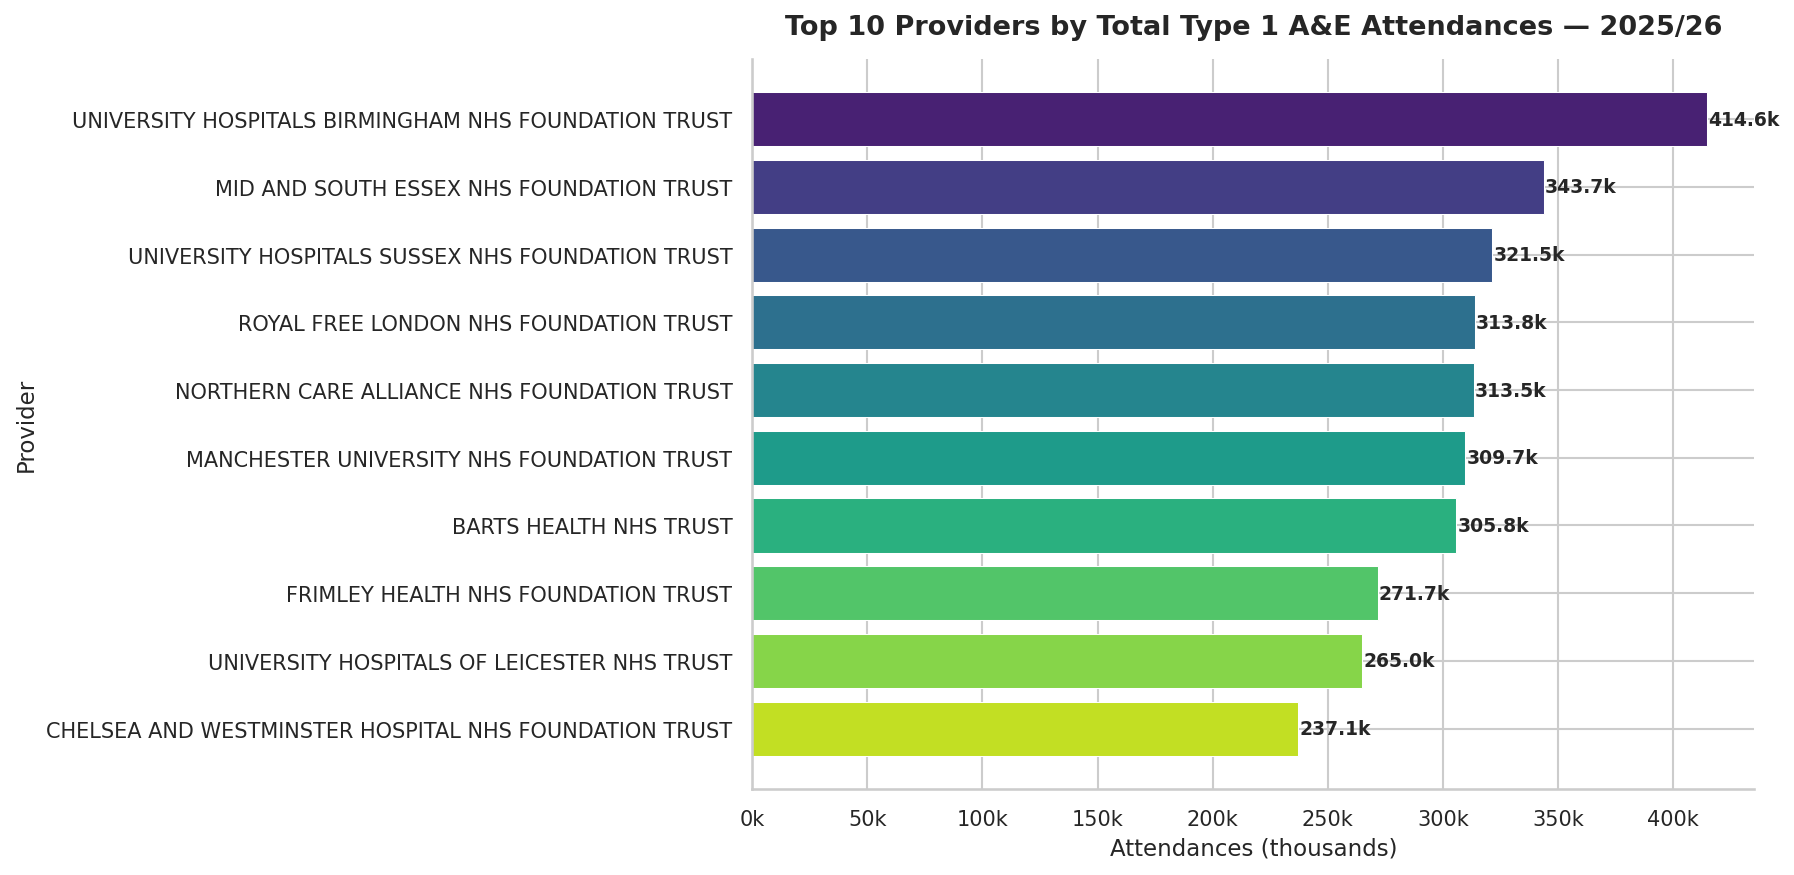

Analysis 4 complete
Highest volume provider: UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST (414,623 attendances)
10th highest provider:   CHELSEA AND WESTMINSTER HOSPITAL NHS FOUNDATION TRUST (237,084 attendances)

Top 10 providers:
                                             Provider  Type1_Attendances
 UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST             414623
             MID AND SOUTH ESSEX NHS FOUNDATION TRUST             343747
     UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST             321536
               ROYAL FREE LONDON NHS FOUNDATION TRUST             313776
          NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST             313494
           MANCHESTER UNIVERSITY NHS FOUNDATION TRUST             309660
                               BARTS HEALTH NHS TRUST             305760
                  FRIMLEY HEALTH NHS FOUNDATION TRUST             271749
          UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST             264994
CHELSEA AND WESTMINSTER HOSPIT

In [9]:

# Aggregate Type 1 attendances by provider across all 12 months
top10 = (
    raw.groupby('org_name')['att_t1']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10.columns = ['Provider', 'Type1_Attendances']

fig, ax = plt.subplots(figsize=(12, 6))

# Horizontal bar chart with viridis colour palette
colors = sns.color_palette('viridis', 10)
bars = ax.barh(
    top10['Provider'][::-1],
    top10['Type1_Attendances'][::-1] / 1000,
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5
)

# Add value labels at end of each bar
for bar, val in zip(bars, top10['Type1_Attendances'][::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val / 1000:.1f}k',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Top 10 Providers by Total Type 1 A&E Attendances — 2025/26',
    fontweight='bold', pad=12
)
ax.set_xlabel('Attendances (thousands)')
ax.set_ylabel('Provider')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}k')
)

plt.tight_layout()
plt.savefig('figures/analysis4_top10_providers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 4 complete")
print(f"Highest volume provider: {top10.iloc[0]['Provider']} "
      f"({top10.iloc[0]['Type1_Attendances']:,.0f} attendances)")
print(f"10th highest provider:   {top10.iloc[9]['Provider']} "
      f"({top10.iloc[9]['Type1_Attendances']:,.0f} attendances)")
print()
print("Top 10 providers:")
print(top10.to_string(index=False))

#### Analysis 5: Worst 10 Providers by 4-Hour Breach Rate
The ten NHS providers with the highest Type 1 4-hour breach rates
were identified across the full 2025/26 financial year. A minimum
threshold of 500 Type 1 attendances was applied to exclude low
volume providers where a small number of breaches could produce
a disproportionately high breach rate that would not be meaningful
for comparative analysis. Breach rates were calculated as the
proportion of total Type 1 attendances exceeding the 4-hour standard
across all 12 months combined.

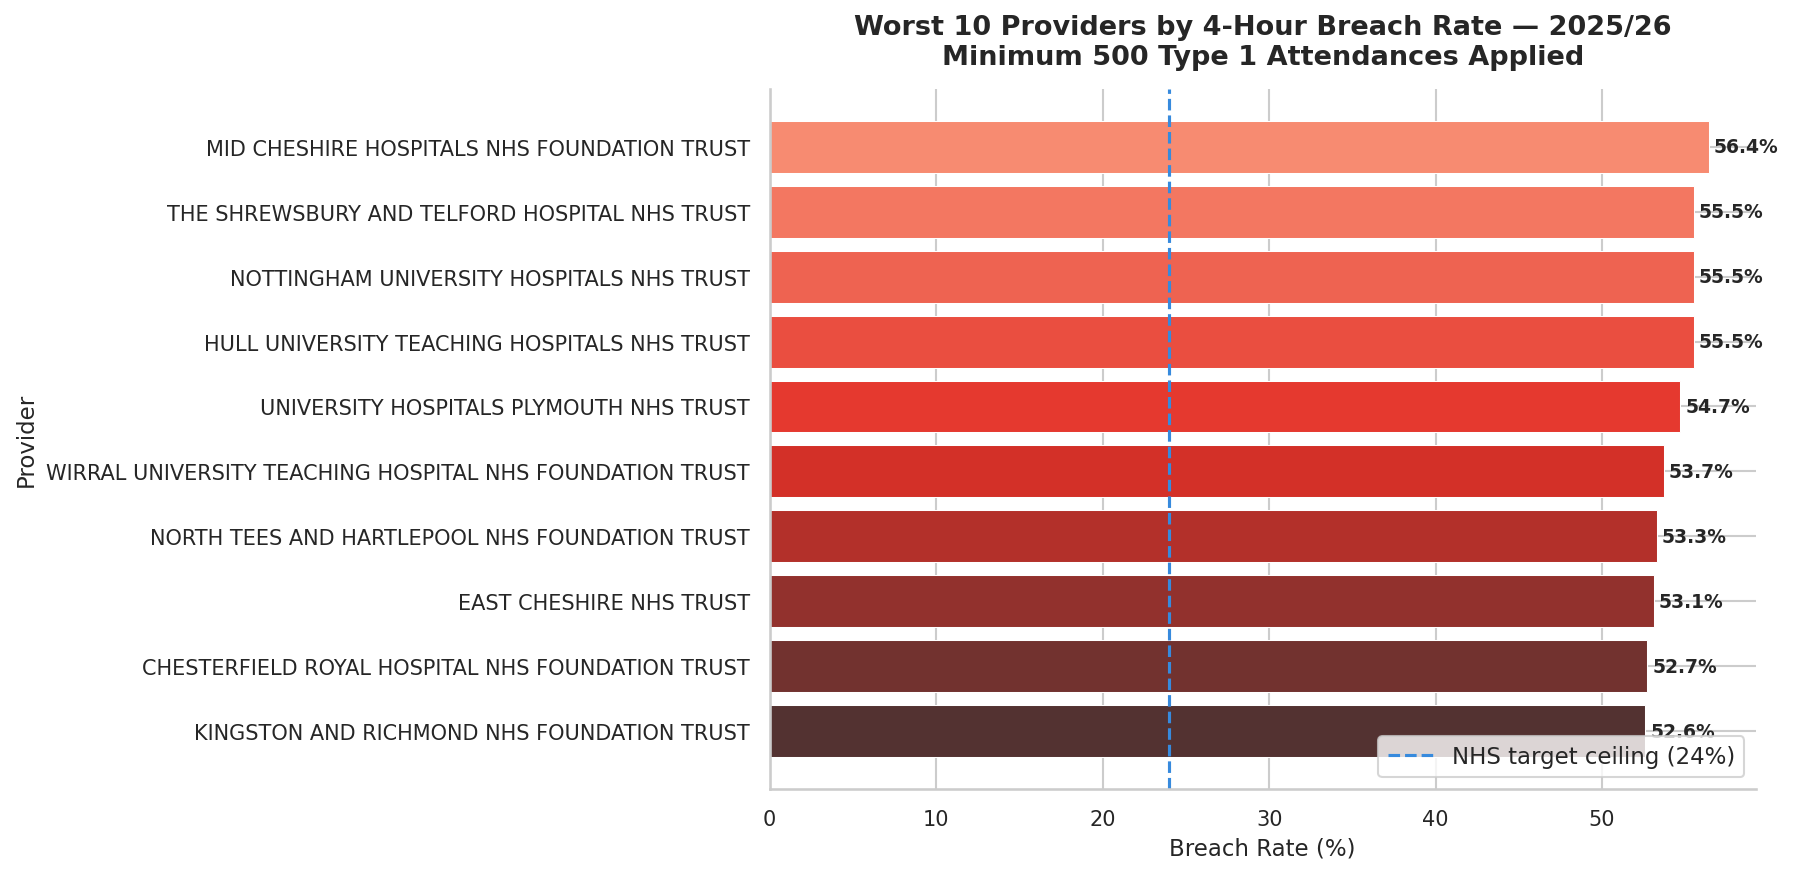

Analysis 5 complete
Highest breach rate: MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST (56.4%)
10th highest:        KINGSTON AND RICHMOND NHS FOUNDATION TRUST (52.6%)

Worst 10 providers by breach rate:
                                                Provider  Breach_Rate_Pct
             MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST             56.4
           THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST             55.5
               NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST             55.5
            HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST             55.5
                 UNIVERSITY HOSPITALS PLYMOUTH NHS TRUST             54.7
WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDATION TRUST             53.7
          NORTH TEES AND HARTLEPOOL NHS FOUNDATION TRUST             53.3
                                 EAST CHESHIRE NHS TRUST             53.1
        CHESTERFIELD ROYAL HOSPITAL NHS FOUNDATION TRUST             52.7
              KINGSTON AND RICHMOND NHS FOUNDATION TRUST   

In [10]:

# Filter to providers with at least 500 Type 1 attendances across the year
# This threshold excludes low volume providers where rates are not meaningfully comparable
worst10 = (
    raw[raw['att_t1'] >= 500]
    .groupby('org_name')
    .apply(lambda g: g['over4_t1'].sum() / g['att_t1'].sum() * 100)
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
worst10.columns = ['Provider', 'Breach_Rate_Pct']
worst10['Breach_Rate_Pct'] = worst10['Breach_Rate_Pct'].round(1)

fig, ax = plt.subplots(figsize=(12, 6))

# Horizontal bar chart with red palette to signal poor performance
bars = ax.barh(
    worst10['Provider'][::-1],
    worst10['Breach_Rate_Pct'][::-1],
    color=sns.color_palette('Reds_d', 10)[::-1],
    edgecolor='white',
    linewidth=0.5
)

# NHS target ceiling reference line
ax.axvline(
    24,
    color='#378ADD',
    linestyle='--',
    linewidth=1.5,
    label='NHS target ceiling (24%)'
)

# Add value labels at end of each bar
for bar, val in zip(bars, worst10['Breach_Rate_Pct'][::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Worst 10 Providers by 4-Hour Breach Rate — 2025/26\n'
    'Minimum 500 Type 1 Attendances Applied',
    fontweight='bold', pad=12
)
ax.set_xlabel('Breach Rate (%)')
ax.set_ylabel('Provider')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('figures/analysis5_worst10_breach.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 5 complete")
print(f"Highest breach rate: {worst10.iloc[0]['Provider']} "
      f"({worst10.iloc[0]['Breach_Rate_Pct']}%)")
print(f"10th highest:        {worst10.iloc[9]['Provider']} "
      f"({worst10.iloc[9]['Breach_Rate_Pct']}%)")
print()
print("Worst 10 providers by breach rate:")
print(worst10.to_string(index=False))

#### Analysis 6: Monthly Emergency Admissions Trend
Total emergency admissions via A&E were tracked across all 12 months
of the 2025/26 financial year. Emergency admissions were combined
across all admission routes including Type 1, Type 2, other A&E
departments and other emergency routes to produce a national monthly
total. This metric reflects the volume of patients presenting at
A&E whose condition required hospital admission rather than
discharge or transfer.

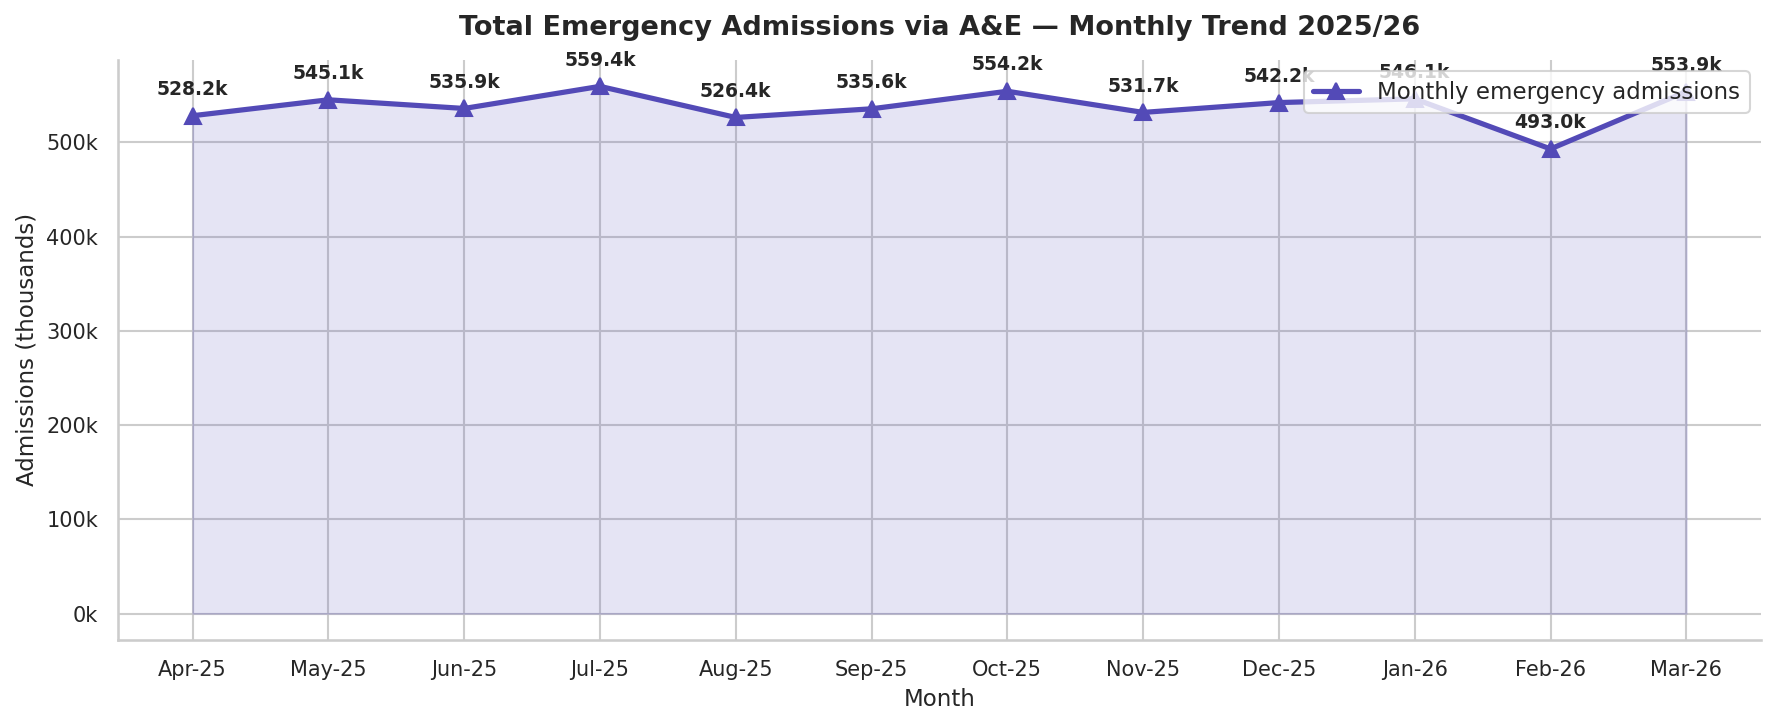

Analysis 6 complete
Highest month: Jul-25 (559,392 admissions)
Lowest month:  Feb-26 (493,015 admissions)
Annual total:  6,451,848 emergency admissions


In [11]:
# Analysis 6: Monthly Emergency Admissions Trend

fig, ax = plt.subplots(figsize=(12, 5))

# Trend line with markers
ax.plot(
    monthly['Month'],
    monthly['total_emerg'] / 1000,
    marker='^',
    linewidth=2.5,
    color='#534AB7',
    markersize=8,
    label='Monthly emergency admissions'
)

# Shaded area under trend line for visual impact
ax.fill_between(
    monthly['Month'],
    monthly['total_emerg'] / 1000,
    alpha=0.15,
    color='#534AB7'
)

# Add data labels above each data point
for month, val in zip(monthly['Month'], monthly['total_emerg']):
    ax.annotate(
        f'{val / 1000:.1f}k',
        (month, val / 1000),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Total Emergency Admissions via A&E — Monthly Trend 2025/26',
    fontweight='bold', pad=12
)
ax.set_ylabel('Admissions (thousands)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}k')
)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/analysis6_emergency_admissions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 6 complete")
print(f"Highest month: {monthly.loc[monthly['total_emerg'].idxmax(), 'Month']} "
      f"({monthly['total_emerg'].max():,.0f} admissions)")
print(f"Lowest month:  {monthly.loc[monthly['total_emerg'].idxmin(), 'Month']} "
      f"({monthly['total_emerg'].min():,.0f} admissions)")
print(f"Annual total:  {monthly['total_emerg'].sum():,.0f} emergency admissions")

#### Analysis 7: A&E Attendance Volume by NHS England Region
Total A&E attendances were analysed by NHS England region across
the full 2025/26 financial year to identify regional variation in
emergency care demand. Attendances across all department types were
combined to produce a total figure for each region, reflecting the
overall scale of emergency care activity across England.

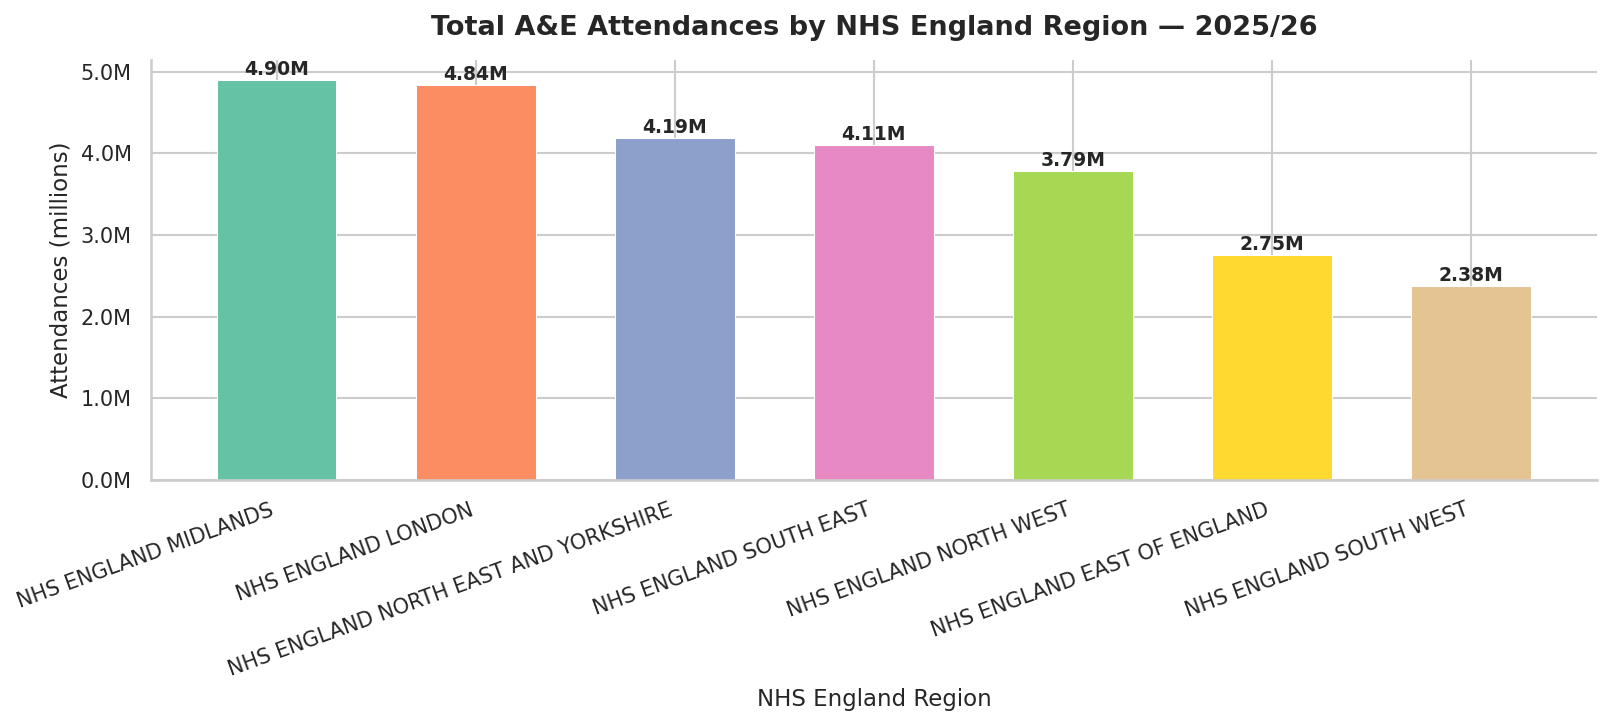

Analysis 7 complete
Busiest region:  NHS ENGLAND MIDLANDS (4.90M attendances)
Quietest region: NHS ENGLAND SOUTH WEST (2.38M attendances)

All regions by total attendance:
                              Region  Total_Attendances
                NHS ENGLAND MIDLANDS            4899893
                  NHS ENGLAND LONDON            4844022
NHS ENGLAND NORTH EAST AND YORKSHIRE            4192609
              NHS ENGLAND SOUTH EAST            4109133
              NHS ENGLAND NORTH WEST            3790594
         NHS ENGLAND EAST OF ENGLAND            2752778
              NHS ENGLAND SOUTH WEST            2375997


In [12]:

# Aggregate total attendances by NHS England region across all 12 months
regional = (
    raw.groupby('region')['total_att']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
regional.columns = ['Region', 'Total_Attendances']

fig, ax = plt.subplots(figsize=(11, 5))

# Bar chart with distinct colour palette for regional differentiation
bars = ax.bar(
    regional['Region'],
    regional['Total_Attendances'] / 1_000_000,
    color=sns.color_palette('Set2', len(regional)),
    width=0.6,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels above each bar
for bar, val in zip(bars, regional['Total_Attendances']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val / 1e6:.2f}M',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Total A&E Attendances by NHS England Region — 2025/26',
    fontweight='bold', pad=12
)
ax.set_ylabel('Attendances (millions)')
ax.set_xlabel('NHS England Region')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}M')
)
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig('figures/analysis7_regional_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 7 complete")
print(f"Busiest region:  {regional.iloc[0]['Region']} "
      f"({regional.iloc[0]['Total_Attendances'] / 1e6:.2f}M attendances)")
print(f"Quietest region: {regional.iloc[-1]['Region']} "
      f"({regional.iloc[-1]['Total_Attendances'] / 1e6:.2f}M attendances)")
print()
print("All regions by total attendance:")
print(regional.to_string(index=False))

#### Analysis 8: Winter Pressure — December 2025 to February 2026
The impact of winter pressure on A&E performance was assessed by
comparing average monthly attendance volumes, 12 hour or longer
wait volumes and 4-hour breach rates across the winter period
from December 2025 to February 2026 against the remaining nine
months of the financial year. This comparison quantifies the
additional operational burden placed on NHS emergency departments
during the winter period.

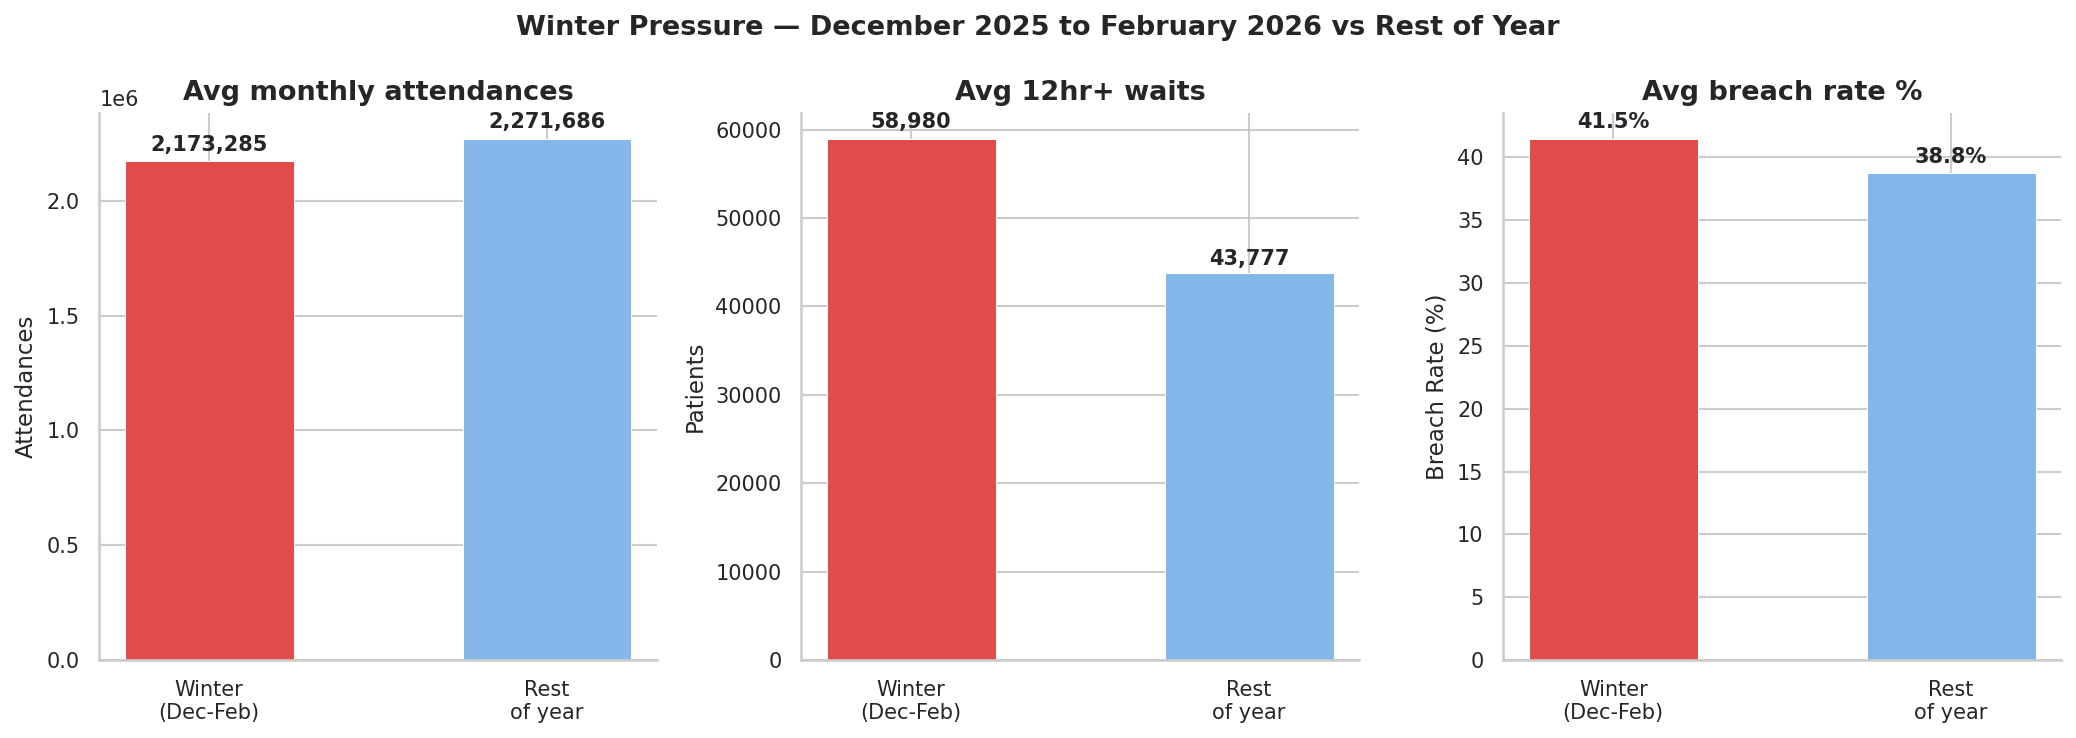

Analysis 8 complete
Winter vs rest of year comparison:
  Attendance multiplier:  0.96x
  12hr+ wait multiplier:  1.35x
  Winter breach rate:     41.5%
  Rest of year rate:      38.8%
  Breach rate difference: 2.7 percentage points


In [13]:

# Separate winter months from the rest of the financial year
winter = raw[raw['Month'].isin(['Dec-25', 'Jan-26', 'Feb-26'])]
rest   = raw[~raw['Month'].isin(['Dec-25', 'Jan-26', 'Feb-26'])]

# Build comparative summary table
winter_summary = pd.DataFrame({
    'Period': ['Winter\n(Dec-Feb)', 'Rest\nof year'],
    'Avg monthly\nattendances': [
        winter.groupby('Month', observed=True)['total_att'].sum().mean(),
        rest.groupby('Month', observed=True)['total_att'].sum().mean(),
    ],
    'Avg 12hr+\nwaits': [
        winter.groupby('Month', observed=True)['wait_12plus'].sum().mean(),
        rest.groupby('Month', observed=True)['wait_12plus'].sum().mean(),
    ],
    'Avg breach\nrate %': [
        winter['over4_t1'].sum() / winter['att_t1'].sum() * 100,
        rest['over4_t1'].sum() / rest['att_t1'].sum() * 100,
    ]
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['Avg monthly\nattendances', 'Avg 12hr+\nwaits', 'Avg breach\nrate %']
ylabels = ['Attendances', 'Patients', 'Breach Rate (%)']
colours = ['#E24B4A', '#85B7EB']  # Red for winter, blue for rest of year

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    bars = ax.bar(
        winter_summary['Period'],
        winter_summary[metric],
        color=colours,
        width=0.5,
        edgecolor='white',
        linewidth=0.5
    )
    ax.set_title(metric.replace('\n', ' '), fontweight='bold')
    ax.set_ylabel(ylabel)

    # Add value labels above each bar
    for bar, val in zip(bars, winter_summary[metric]):
        label = f'{val:,.0f}' if val > 100 else f'{val:.1f}%'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            label,
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

fig.suptitle(
    'Winter Pressure — December 2025 to February 2026 vs Rest of Year',
    fontweight='bold',
    fontsize=13
)

plt.tight_layout()
plt.savefig('figures/analysis8_winter_pressure.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 8 complete")

# Calculate and display winter impact ratios
winter_att   = winter.groupby('Month', observed=True)['total_att'].sum().mean()
rest_att     = rest.groupby('Month', observed=True)['total_att'].sum().mean()
winter_waits = winter.groupby('Month', observed=True)['wait_12plus'].sum().mean()
rest_waits   = rest.groupby('Month', observed=True)['wait_12plus'].sum().mean()
winter_breach = winter['over4_t1'].sum() / winter['att_t1'].sum() * 100
rest_breach   = rest['over4_t1'].sum() / rest['att_t1'].sum() * 100

print(f"Winter vs rest of year comparison:")
print(f"  Attendance multiplier:  {winter_att / rest_att:.2f}x")
print(f"  12hr+ wait multiplier:  {winter_waits / rest_waits:.2f}x")
print(f"  Winter breach rate:     {winter_breach:.1f}%")
print(f"  Rest of year rate:      {rest_breach:.1f}%")
print(f"  Breach rate difference: {winter_breach - rest_breach:.1f} percentage points")

#### Analysis 9: Full Year Summary Scorecard
A consolidated summary scorecard was produced combining the key
national performance metrics across the full 2025/26 financial
year. The scorecard presents total attendance volumes, emergency
admission counts, long wait volumes, the overall breach rate and
identifies the peak and worst performing months across the year.

In [14]:

# Calculate full year national performance metrics
total_att      = raw['total_att'].sum()
total_emerg    = raw['total_emerg'].sum()
total_12hr     = raw['wait_12plus'].sum()
overall_breach = raw['over4_t1'].sum() / raw['att_t1'].sum() * 100
peak_month     = monthly.loc[monthly['total_att'].idxmax(), 'Month']
worst_month    = monthly.loc[monthly['breach_rate_pct'].idxmax(), 'Month']
best_month     = monthly.loc[monthly['breach_rate_pct'].idxmin(), 'Month']
emerg_rate     = total_emerg / total_att * 100

# Display full year summary scorecard
print("=" * 60)
print("   NHS A&E PERFORMANCE SCORECARD — 2025/26 FINANCIAL YEAR")
print("=" * 60)
print(f"  Total A&E attendances          : {total_att:>12,.0f}")
print(f"  Total emergency admissions     : {total_emerg:>12,.0f}")
print(f"  Emergency admission rate       : {emerg_rate:>11.1f}%")
print(f"  Total 12 hour or longer waits  : {total_12hr:>12,.0f}")
print(f"  Overall 4-hour breach rate     : {overall_breach:>11.1f}%")
print(f"  NHS 4-hour target ceiling      : {'24.0%':>12}")
print(f"  Gap to target                  : {overall_breach - 24:>11.1f} percentage points")
print(f"  Peak month by attendances      : {peak_month}")
print(f"  Worst month by breach rate     : {worst_month}")
print(f"  Best month by breach rate      : {best_month}")
print("=" * 60)
print(f"  NHS missed the 24% target in all {len(monthly)} reporting periods")
print("=" * 60)

   NHS A&E PERFORMANCE SCORECARD — 2025/26 FINANCIAL YEAR
  Total A&E attendances          :   26,965,026
  Total emergency admissions     :    6,451,848
  Emergency admission rate       :        23.9%
  Total 12 hour or longer waits  :      570,931
  Overall 4-hour breach rate     :        39.4%
  NHS 4-hour target ceiling      :        24.0%
  Gap to target                  :        15.4 percentage points
  Peak month by attendances      : Mar-26
  Worst month by breach rate     : Jan-26
  Best month by breach rate      : Mar-26
  NHS missed the 24% target in all 12 reporting periods


#### Analysis 10: Month on Month Performance Change
Monthly changes in A&E attendance volumes and 4-hour breach rates
were calculated across the 2025/26 financial year to identify
whether national performance was improving or deteriorating over
time. Month on month percentage change in attendance volume and
the absolute change in breach rate in percentage points were
calculated to provide a directional view of performance trends
throughout the year.

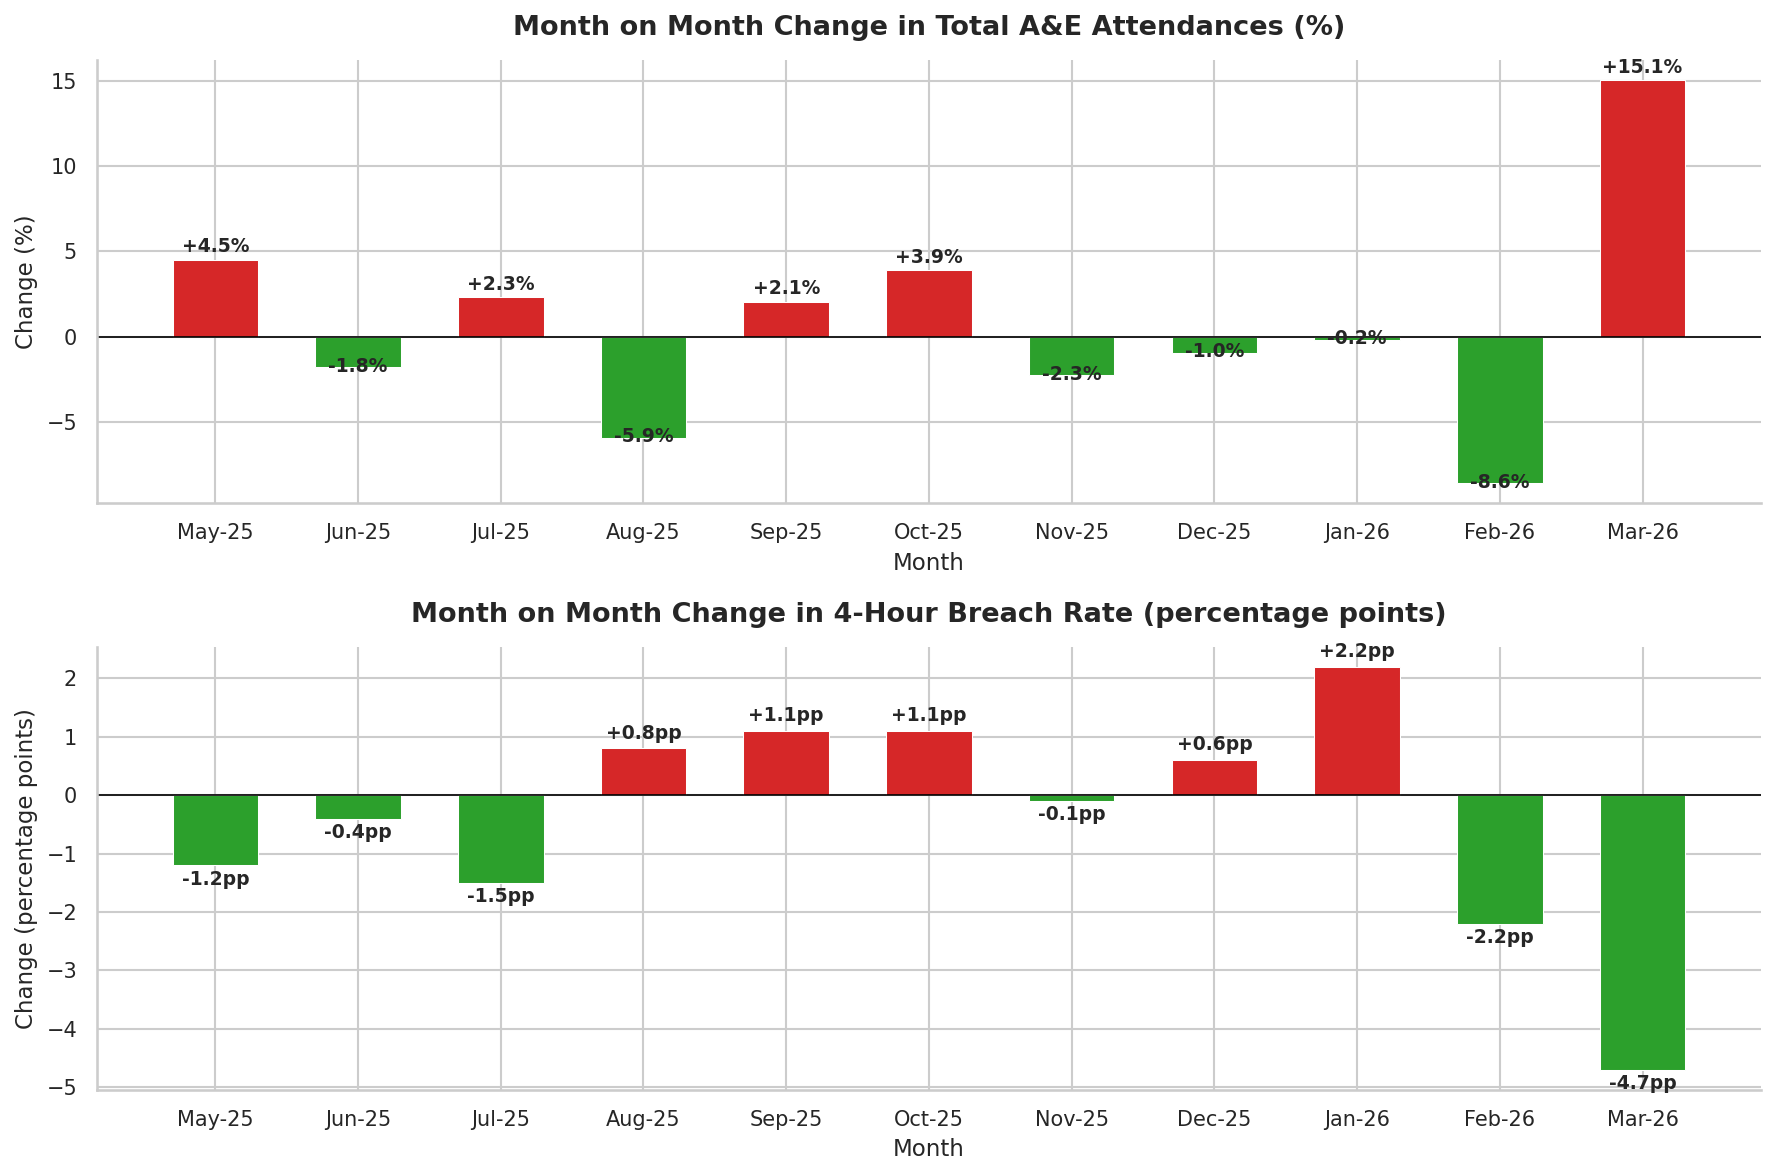

Analysis 10 complete

Attendance changes:
  Largest increase:  Mar-26 (+15.1%)
  Largest decrease:  Feb-26 (-8.6%)

Breach rate changes:
  Largest increase:  Jan-26 (+2.2pp)
  Largest decrease:  Mar-26 (-4.7pp)


In [15]:

# Calculate month on month changes
monthly['att_change_pct'] = monthly['total_att'].pct_change() * 100
monthly['breach_change_pp'] = monthly['breach_rate_pct'].diff()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Chart 1 — Month on month attendance change
colors_att = ['#2ca02c' if x <= 0 else '#d62728'
              for x in monthly['att_change_pct'].fillna(0)]

bars1 = axes[0].bar(
    monthly['Month'],
    monthly['att_change_pct'],
    color=colors_att,
    width=0.6,
    edgecolor='white',
    linewidth=0.5
)

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='-')
axes[0].set_title(
    'Month on Month Change in Total A&E Attendances (%)',
    fontweight='bold', pad=12
)
axes[0].set_ylabel('Change (%)')
axes[0].set_xlabel('Month')

# Add value labels
for bar, val in zip(bars1, monthly['att_change_pct']):
    if pd.notna(val):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.2 if val >= 0 else -0.5),
            f'{val:+.1f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

# Chart 2 — Month on month breach rate change
colors_breach = ['#2ca02c' if x <= 0 else '#d62728'
                 for x in monthly['breach_change_pp'].fillna(0)]

bars2 = axes[1].bar(
    monthly['Month'],
    monthly['breach_change_pp'],
    color=colors_breach,
    width=0.6,
    edgecolor='white',
    linewidth=0.5
)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='-')
axes[1].set_title(
    'Month on Month Change in 4-Hour Breach Rate (percentage points)',
    fontweight='bold', pad=12
)
axes[1].set_ylabel('Change (percentage points)')
axes[1].set_xlabel('Month')

# Add value labels
for bar, val in zip(bars2, monthly['breach_change_pp']):
    if pd.notna(val):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.1 if val >= 0 else -0.4),
            f'{val:+.1f}pp',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('figures/analysis10_month_on_month_change.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 10 complete")
print(f"\nAttendance changes:")
print(f"  Largest increase:  {monthly.loc[monthly['att_change_pct'].idxmax(), 'Month']} "
      f"({monthly['att_change_pct'].max():+.1f}%)")
print(f"  Largest decrease:  {monthly.loc[monthly['att_change_pct'].idxmin(), 'Month']} "
      f"({monthly['att_change_pct'].min():+.1f}%)")
print(f"\nBreach rate changes:")
print(f"  Largest increase:  {monthly.loc[monthly['breach_change_pp'].idxmax(), 'Month']} "
      f"({monthly['breach_change_pp'].max():+.1f}pp)")
print(f"  Largest decrease:  {monthly.loc[monthly['breach_change_pp'].idxmin(), 'Month']} "
      f"({monthly['breach_change_pp'].min():+.1f}pp)")

#### Analysis 11: Best 10 Performing Providers by 4-Hour Breach Rate
The ten NHS providers with the lowest Type 1 4-hour breach rates
were identified across the full 2025/26 financial year. The same
minimum threshold of 500 Type 1 attendances applied in Analysis 5
was used to ensure only providers with meaningful attendance volumes
were included. This analysis completes the provider performance
picture by identifying what good performance looks like alongside
the worst performing providers identified in Analysis 5.

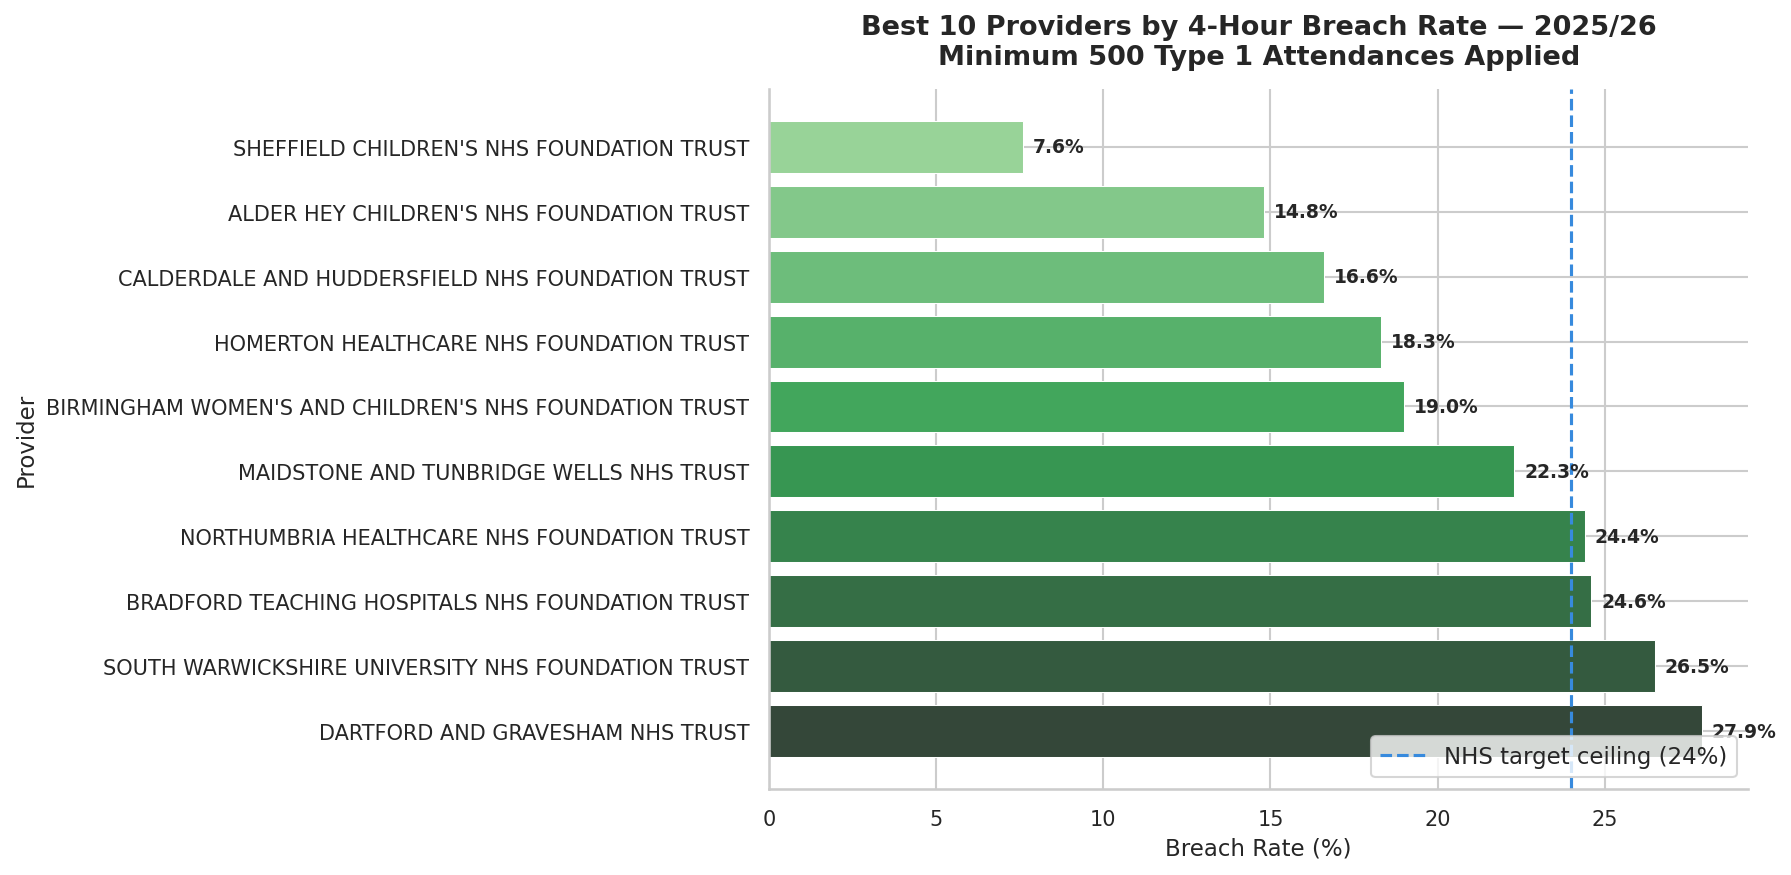

Analysis 11 complete
Lowest breach rate:  SHEFFIELD CHILDREN'S NHS FOUNDATION TRUST (7.6%)
10th lowest:         DARTFORD AND GRAVESHAM NHS TRUST (27.9%)

Best 10 providers by breach rate:
                                              Provider  Breach_Rate_Pct
             SHEFFIELD CHILDREN'S NHS FOUNDATION TRUST              7.6
             ALDER HEY CHILDREN'S NHS FOUNDATION TRUST             14.8
      CALDERDALE AND HUDDERSFIELD NHS FOUNDATION TRUST             16.6
              HOMERTON HEALTHCARE NHS FOUNDATION TRUST             18.3
BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATION TRUST             19.0
               MAIDSTONE AND TUNBRIDGE WELLS NHS TRUST             22.3
           NORTHUMBRIA HEALTHCARE NHS FOUNDATION TRUST             24.4
      BRADFORD TEACHING HOSPITALS NHS FOUNDATION TRUST             24.6
    SOUTH WARWICKSHIRE UNIVERSITY NHS FOUNDATION TRUST             26.5
                      DARTFORD AND GRAVESHAM NHS TRUST             27.9


In [16]:

# Filter to providers with at least 500 Type 1 attendances across the year
best10 = (
    raw[raw['att_t1'] >= 500]
    .groupby('org_name')
    .apply(lambda g: g['over4_t1'].sum() / g['att_t1'].sum() * 100)
    .sort_values(ascending=True)
    .head(10)
    .reset_index()
)
best10.columns = ['Provider', 'Breach_Rate_Pct']
best10['Breach_Rate_Pct'] = best10['Breach_Rate_Pct'].round(1)

fig, ax = plt.subplots(figsize=(12, 6))

# Horizontal bar chart with green palette to signal good performance
bars = ax.barh(
    best10['Provider'][::-1],
    best10['Breach_Rate_Pct'][::-1],
    color=sns.color_palette('Greens_d', 10)[::-1],
    edgecolor='white',
    linewidth=0.5
)

# NHS target ceiling reference line
ax.axvline(
    24,
    color='#378ADD',
    linestyle='--',
    linewidth=1.5,
    label='NHS target ceiling (24%)'
)

# Add value labels at end of each bar
for bar, val in zip(bars, best10['Breach_Rate_Pct'][::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Best 10 Providers by 4-Hour Breach Rate — 2025/26\n'
    'Minimum 500 Type 1 Attendances Applied',
    fontweight='bold', pad=12
)
ax.set_xlabel('Breach Rate (%)')
ax.set_ylabel('Provider')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('figures/analysis11_best10_providers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 11 complete")
print(f"Lowest breach rate:  {best10.iloc[0]['Provider']} "
      f"({best10.iloc[0]['Breach_Rate_Pct']}%)")
print(f"10th lowest:         {best10.iloc[9]['Provider']} "
      f"({best10.iloc[9]['Breach_Rate_Pct']}%)")
print()
print("Best 10 providers by breach rate:")
print(best10.to_string(index=False))

#### Analysis 12: Regional 4-Hour Breach Rate Comparison
4-hour breach rates were calculated and compared across all NHS
England regions for the full 2025/26 financial year. This analysis
extends the regional attendance volume analysis in Analysis 7 by
adding a performance dimension, enabling a direct comparison of
both demand and performance variation across England.

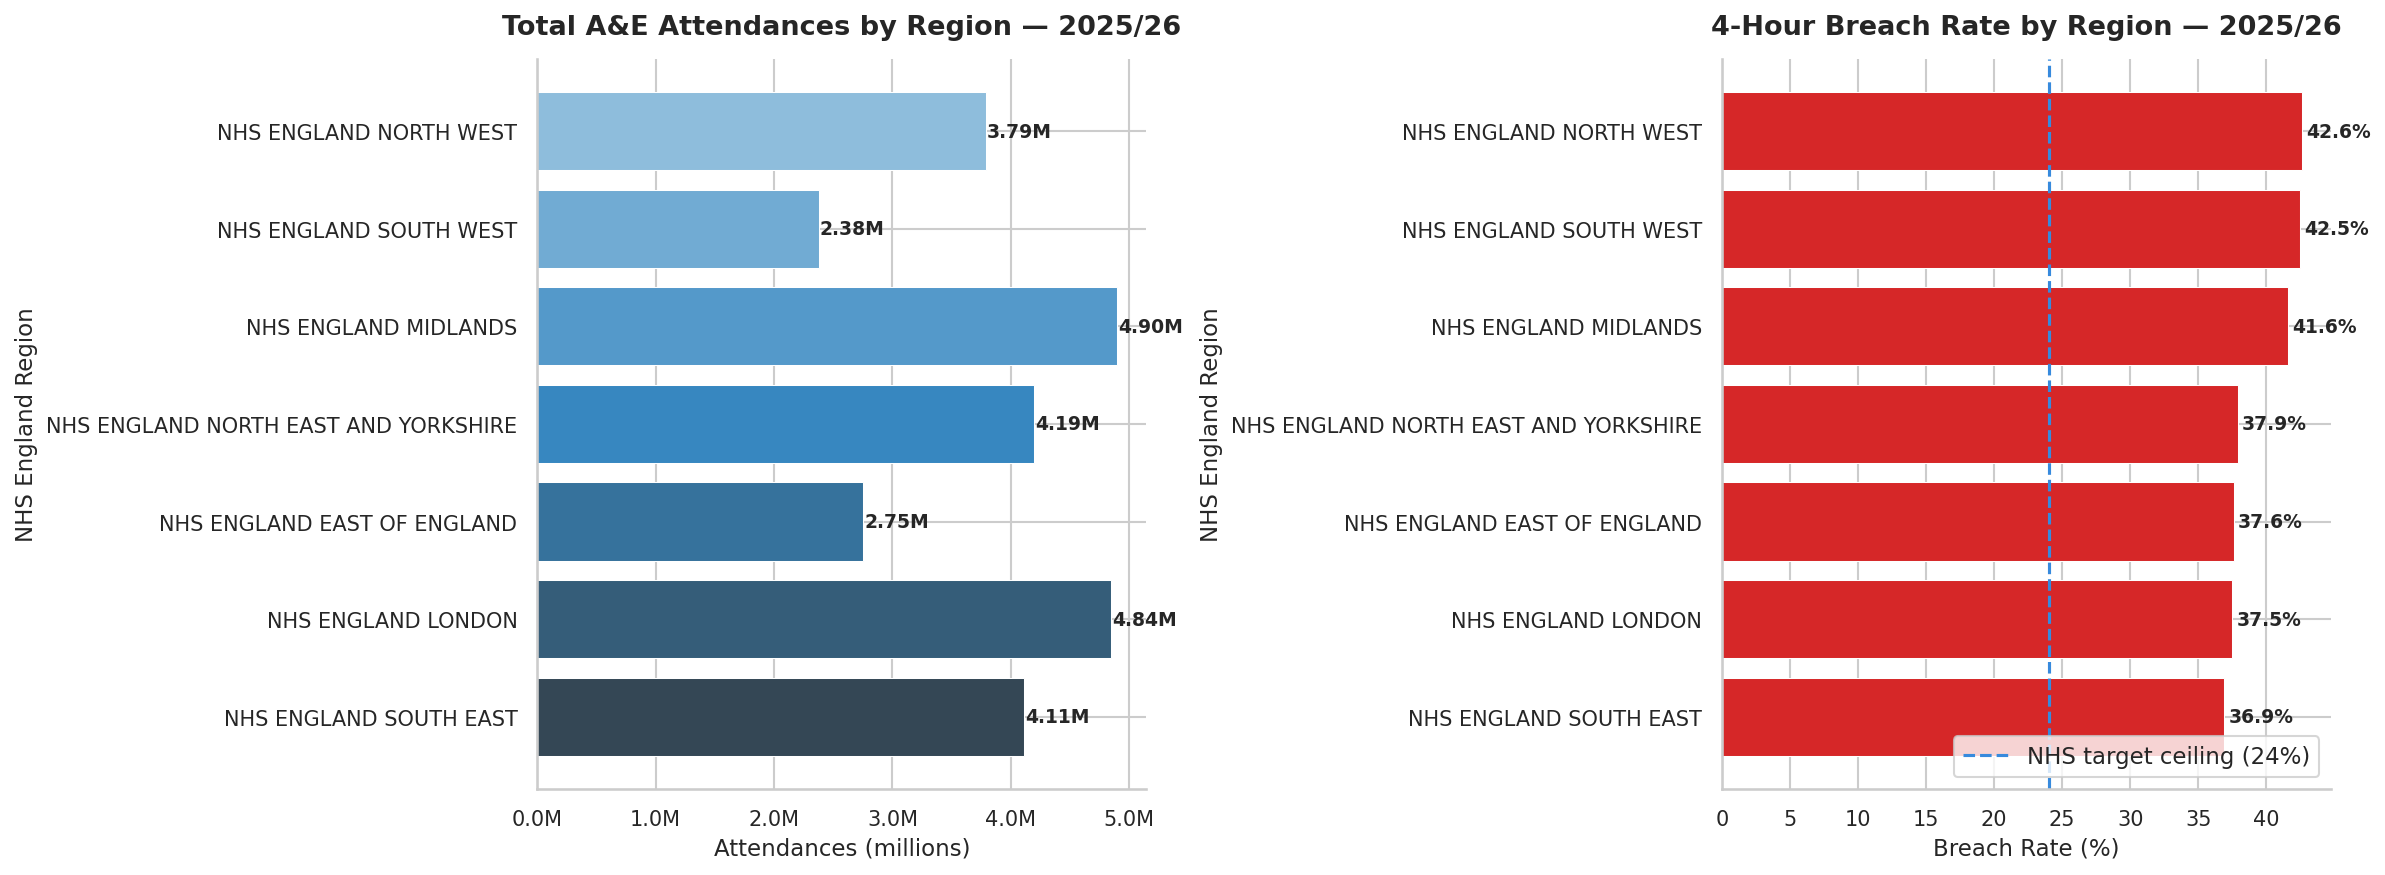

Analysis 12 complete

Highest breach rate region: NHS ENGLAND NORTH WEST (42.6%)
Lowest breach rate region:  NHS ENGLAND SOUTH EAST (36.9%)

Regional breach rates:
                              region  total_att  breach_rate_pct
              NHS ENGLAND NORTH WEST  3790594.0             42.6
              NHS ENGLAND SOUTH WEST  2375997.0             42.5
                NHS ENGLAND MIDLANDS  4899893.0             41.6
NHS ENGLAND NORTH EAST AND YORKSHIRE  4192609.0             37.9
         NHS ENGLAND EAST OF ENGLAND  2752778.0             37.6
                  NHS ENGLAND LONDON  4844022.0             37.5
              NHS ENGLAND SOUTH EAST  4109133.0             36.9


In [17]:

# Calculate breach rate by region across all 12 months
regional_breach = (
    raw.groupby('region')
    .apply(lambda g: pd.Series({
        'total_att': g['total_att'].sum(),
        'att_t1': g['att_t1'].sum(),
        'over4_t1': g['over4_t1'].sum(),
        'breach_rate_pct': round(g['over4_t1'].sum() / g['att_t1'].sum() * 100, 1)
        if g['att_t1'].sum() > 0 else 0
    }))
    .reset_index()
    .sort_values('breach_rate_pct', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Regional attendance volumes
colors_att = sns.color_palette('Blues_d', len(regional_breach))
bars1 = axes[0].barh(
    regional_breach['region'][::-1],
    regional_breach['total_att'][::-1] / 1_000_000,
    color=colors_att[::-1],
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_title(
    'Total A&E Attendances by Region — 2025/26',
    fontweight='bold', pad=12
)
axes[0].set_xlabel('Attendances (millions)')
axes[0].set_ylabel('NHS England Region')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}M')
)
for bar, val in zip(bars1, regional_breach['total_att'][::-1]):
    axes[0].text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val / 1e6:.2f}M',
        va='center', fontsize=9, fontweight='bold'
    )

# Chart 2 — Regional breach rates
colors_breach = ['#d62728' if x > 24 else '#2ca02c'
                 for x in regional_breach['breach_rate_pct'][::-1]]
bars2 = axes[1].barh(
    regional_breach['region'][::-1],
    regional_breach['breach_rate_pct'][::-1],
    color=colors_breach,
    edgecolor='white',
    linewidth=0.5
)
axes[1].axvline(
    24,
    color='#378ADD',
    linestyle='--',
    linewidth=1.5,
    label='NHS target ceiling (24%)'
)
axes[1].set_title(
    '4-Hour Breach Rate by Region — 2025/26',
    fontweight='bold', pad=12
)
axes[1].set_xlabel('Breach Rate (%)')
axes[1].set_ylabel('NHS England Region')
axes[1].legend(loc='lower right')
for bar, val in zip(bars2, regional_breach['breach_rate_pct'][::-1]):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('figures/analysis12_regional_breach.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 12 complete")
print(f"\nHighest breach rate region: "
      f"{regional_breach.iloc[0]['region']} "
      f"({regional_breach.iloc[0]['breach_rate_pct']}%)")
print(f"Lowest breach rate region:  "
      f"{regional_breach.iloc[-1]['region']} "
      f"({regional_breach.iloc[-1]['breach_rate_pct']}%)")
print()
print("Regional breach rates:")
print(regional_breach[['region', 'total_att', 'breach_rate_pct']].to_string(index=False))

#### Analysis 13: ICB Level Performance Analysis
4-hour breach rates were calculated at Integrated Care Board level
to identify which commissioning areas recorded the highest and lowest
performance across the full 2025/26 financial year. ICBs are the
bodies accountable for commissioning and performance managing NHS
services within their geography. The top 10 and bottom 10 performing
ICBs were identified using the same minimum attendance threshold
applied in provider level analyses.

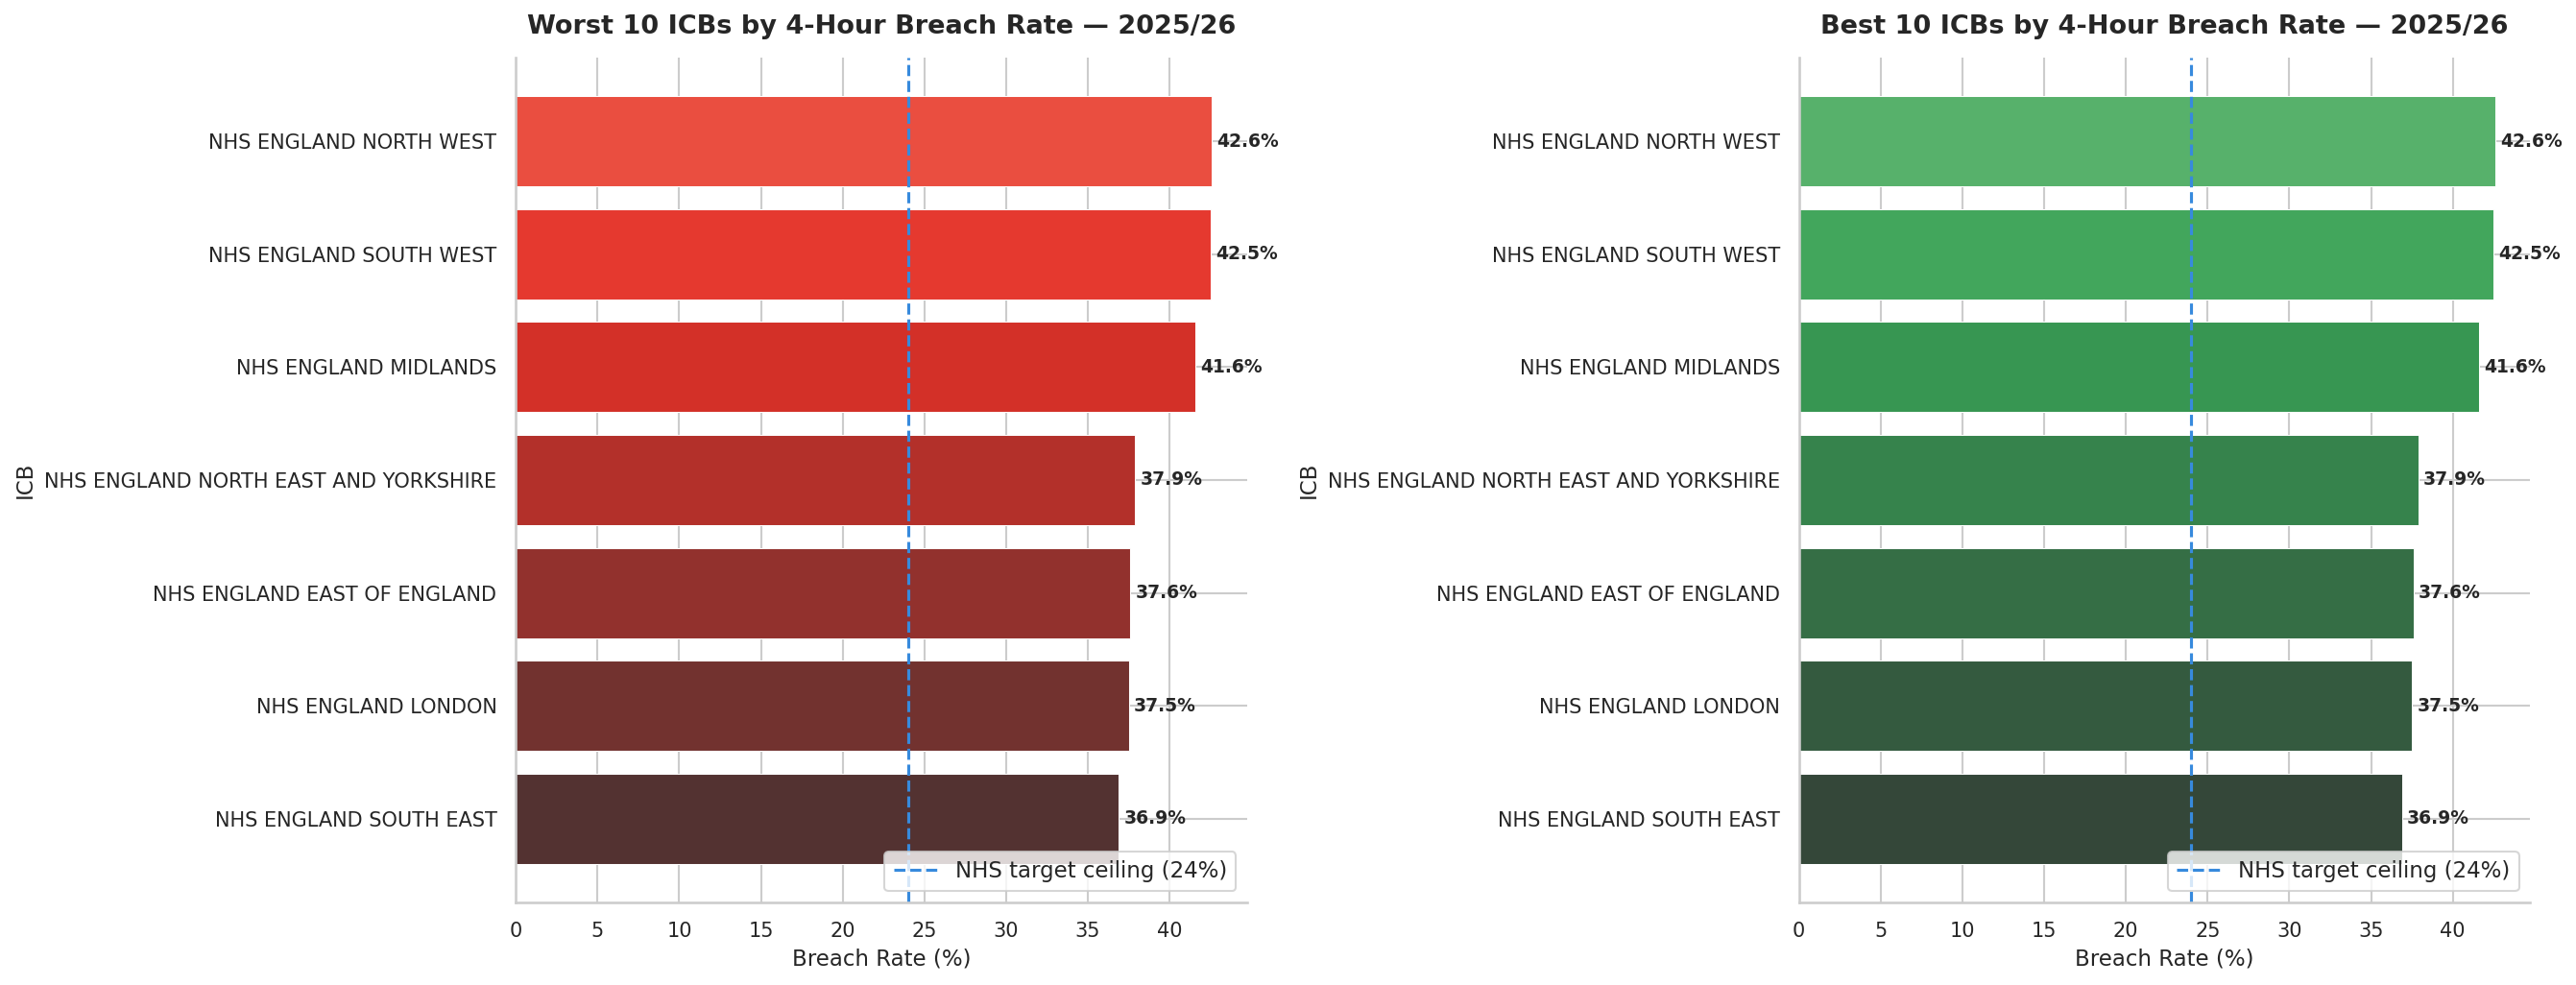

Analysis 13 complete

Worst performing ICB:  NHS ENGLAND NORTH WEST (42.6%)
Best performing ICB:   NHS ENGLAND SOUTH EAST (36.9%)


In [18]:

# Calculate breach rate by ICB — using Parent Org as ICB identifier
icb_perf = (
    raw[raw['att_t1'] >= 100]
    .groupby('region')
    .apply(lambda g: pd.Series({
        'total_att_t1': g['att_t1'].sum(),
        'total_over4': g['over4_t1'].sum(),
        'breach_rate_pct': round(
            g['over4_t1'].sum() / g['att_t1'].sum() * 100, 1)
        if g['att_t1'].sum() > 0 else None
    }))
    .dropna()
    .reset_index()
    .sort_values('breach_rate_pct', ascending=False)
)

# Get top 10 worst and best performing ICBs
worst_icb = icb_perf.head(10)
best_icb  = icb_perf.tail(10).sort_values('breach_rate_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1 — Worst 10 ICBs
bars1 = axes[0].barh(
    worst_icb['region'][::-1],
    worst_icb['breach_rate_pct'][::-1],
    color=sns.color_palette('Reds_d', 10)[::-1],
    edgecolor='white',
    linewidth=0.5
)
axes[0].axvline(
    24,
    color='#378ADD',
    linestyle='--',
    linewidth=1.5,
    label='NHS target ceiling (24%)'
)
axes[0].set_title(
    'Worst 10 ICBs by 4-Hour Breach Rate — 2025/26',
    fontweight='bold', pad=12
)
axes[0].set_xlabel('Breach Rate (%)')
axes[0].set_ylabel('ICB')
axes[0].legend(loc='lower right')
for bar, val in zip(bars1, worst_icb['breach_rate_pct'][::-1]):
    axes[0].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center', fontsize=9, fontweight='bold'
    )

# Chart 2 — Best 10 ICBs
bars2 = axes[1].barh(
    best_icb['region'],
    best_icb['breach_rate_pct'],
    color=sns.color_palette('Greens_d', 10)[::-1],
    edgecolor='white',
    linewidth=0.5
)
axes[1].axvline(
    24,
    color='#378ADD',
    linestyle='--',
    linewidth=1.5,
    label='NHS target ceiling (24%)'
)
axes[1].set_title(
    'Best 10 ICBs by 4-Hour Breach Rate — 2025/26',
    fontweight='bold', pad=12
)
axes[1].set_xlabel('Breach Rate (%)')
axes[1].set_ylabel('ICB')
axes[1].legend(loc='lower right')
for bar, val in zip(bars2, best_icb['breach_rate_pct']):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('figures/analysis13_icb_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 13 complete")
print(f"\nWorst performing ICB:  {worst_icb.iloc[0]['region']} "
      f"({worst_icb.iloc[0]['breach_rate_pct']}%)")
print(f"Best performing ICB:   {best_icb.iloc[0]['region']} "
      f"({best_icb.iloc[0]['breach_rate_pct']}%)")

#### Analysis 14: Provider Performance Consistency
Provider performance was assessed across all 12 months of the
2025/26 financial year to identify providers that consistently
underperformed versus those that only struggled during specific
periods. Providers with at least 6 months of Type 1 attendance
data were included. The standard deviation of monthly breach rates
was used as a measure of performance consistency — a low standard
deviation indicates consistent performance while a high standard
deviation indicates variable performance across the year.

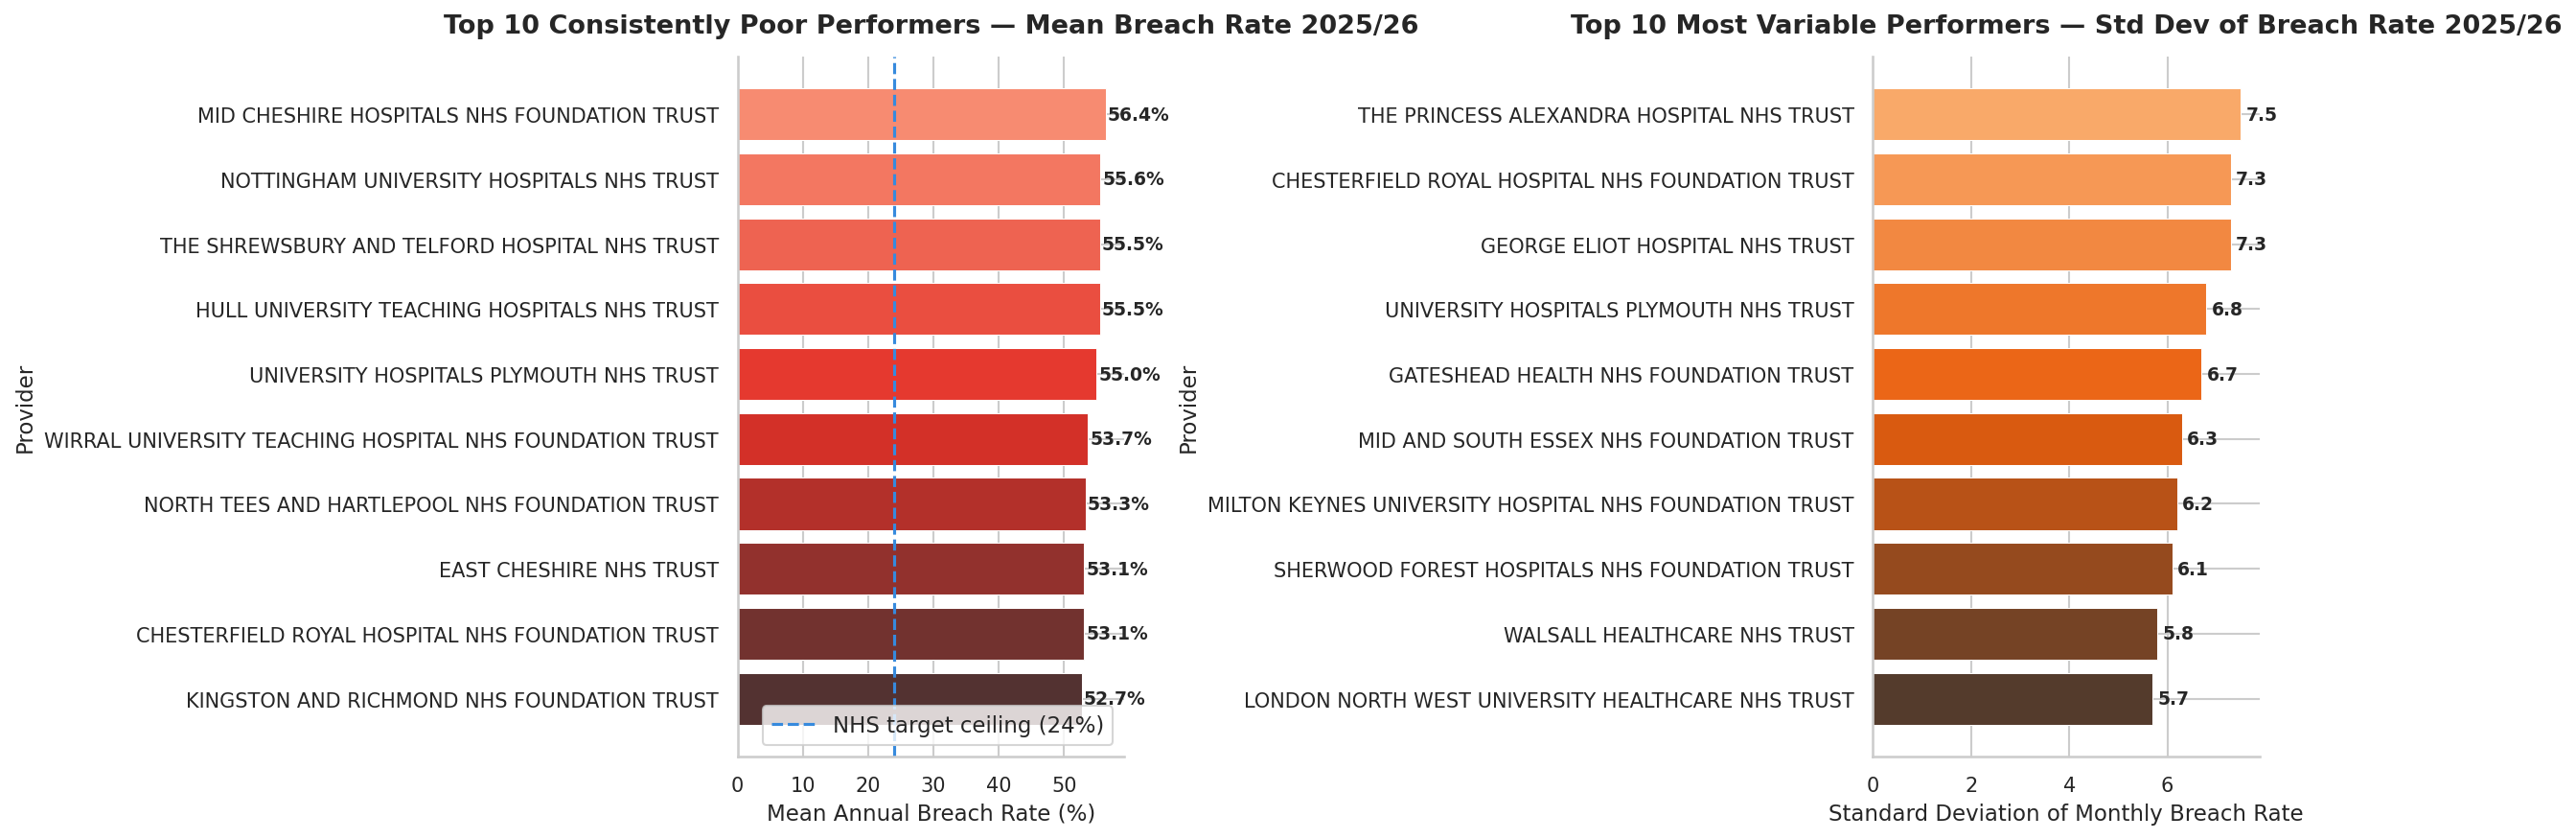

Analysis 14 complete

Most consistently poor performer: MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST (mean 56.4%)
Most variable performer: THE PRINCESS ALEXANDRA HOSPITAL NHS TRUST (std dev 7.5)


In [19]:

# Calculate monthly breach rate per provider
provider_monthly = (
    raw[raw['att_t1'] >= 50]
    .groupby(['org_name', 'Month'], observed=True)
    .apply(lambda g: round(
        g['over4_t1'].sum() / g['att_t1'].sum() * 100, 1)
        if g['att_t1'].sum() > 0 else None
    )
    .reset_index()
)
provider_monthly.columns = ['Provider', 'Month', 'Breach_Rate']
provider_monthly = provider_monthly.dropna()

# Calculate mean and standard deviation of breach rate per provider
# Minimum 6 months of data required for meaningful consistency assessment
provider_consistency = (
    provider_monthly.groupby('Provider')
    .filter(lambda x: len(x) >= 6)
    .groupby('Provider')['Breach_Rate']
    .agg(
        Mean_Breach_Rate='mean',
        Std_Breach_Rate='std',
        Months_Reported='count'
    )
    .round(1)
    .reset_index()
    .sort_values('Mean_Breach_Rate', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Most consistently poor performers
# High mean breach rate AND low standard deviation
consistent_poor = (
    provider_consistency
    .sort_values('Mean_Breach_Rate', ascending=False)
    .head(10)
)
bars1 = axes[0].barh(
    consistent_poor['Provider'][::-1],
    consistent_poor['Mean_Breach_Rate'][::-1],
    color=sns.color_palette('Reds_d', 10)[::-1],
    edgecolor='white',
    linewidth=0.5
)
axes[0].axvline(
    24,
    color='#378ADD',
    linestyle='--',
    linewidth=1.5,
    label='NHS target ceiling (24%)'
)
axes[0].set_title(
    'Top 10 Consistently Poor Performers — Mean Breach Rate 2025/26',
    fontweight='bold', pad=12
)
axes[0].set_xlabel('Mean Annual Breach Rate (%)')
axes[0].set_ylabel('Provider')
axes[0].legend(loc='lower right')
for bar, val in zip(bars1, consistent_poor['Mean_Breach_Rate'][::-1]):
    axes[0].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%',
        va='center', fontsize=9, fontweight='bold'
    )

# Chart 2 — Most variable performers
# High standard deviation indicates inconsistent performance
variable = (
    provider_consistency[provider_consistency['Mean_Breach_Rate'] > 20]
    .sort_values('Std_Breach_Rate', ascending=False)
    .head(10)
)
bars2 = axes[1].barh(
    variable['Provider'][::-1],
    variable['Std_Breach_Rate'][::-1],
    color=sns.color_palette('Oranges_d', 10)[::-1],
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_title(
    'Top 10 Most Variable Performers — Std Dev of Breach Rate 2025/26',
    fontweight='bold', pad=12
)
axes[1].set_xlabel('Standard Deviation of Monthly Breach Rate')
axes[1].set_ylabel('Provider')
for bar, val in zip(bars2, variable['Std_Breach_Rate'][::-1]):
    axes[1].text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{val}',
        va='center', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('figures/analysis14_provider_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 14 complete")
print(f"\nMost consistently poor performer: "
      f"{consistent_poor.iloc[0]['Provider']} "
      f"(mean {consistent_poor.iloc[0]['Mean_Breach_Rate']}%)")
print(f"Most variable performer: "
      f"{variable.iloc[0]['Provider']} "
      f"(std dev {variable.iloc[0]['Std_Breach_Rate']})")

#### Analysis 15: Summary Performance Heatmap
A summary heatmap was produced showing monthly 4-hour breach rates
across the top 20 highest volume Type 1 providers throughout the
2025/26 financial year. The heatmap provides a simultaneous view
of provider level performance variation and seasonal patterns,
enabling direct comparison of performance trajectories across
providers and months in a single visual.

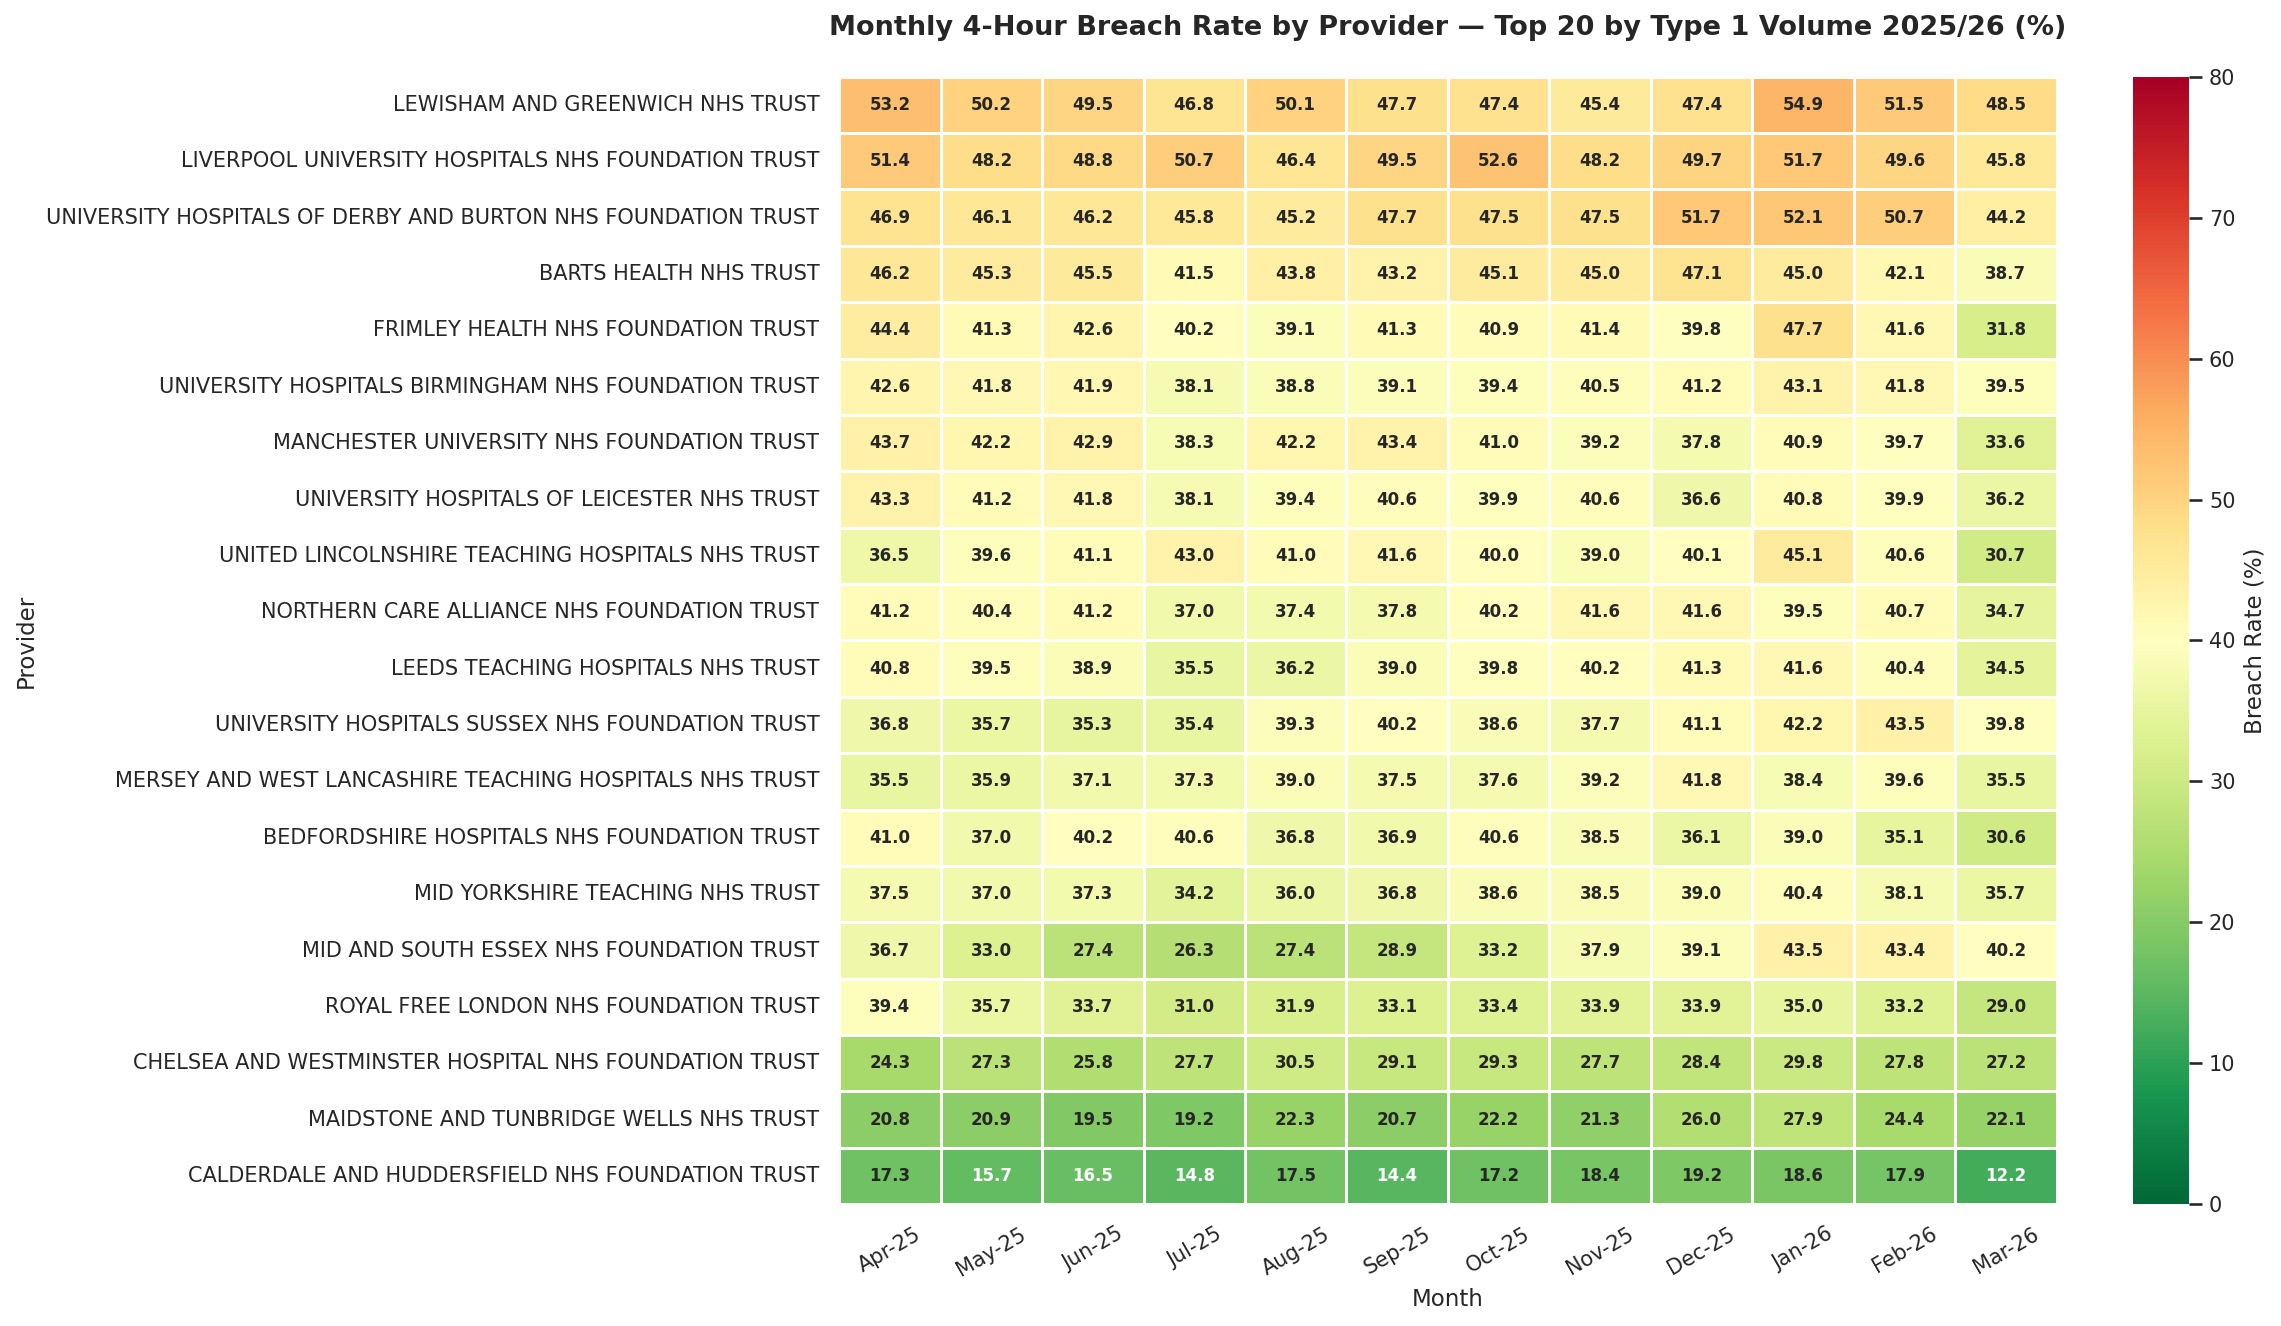

Analysis 15 complete

Providers included: 20
Months covered: 12

Provider with highest mean breach rate: LEWISHAM AND GREENWICH NHS TRUST (49.4%)
Provider with lowest mean breach rate:  CALDERDALE AND HUDDERSFIELD NHS FOUNDATION TRUST (16.6%)


In [20]:

# Select top 20 providers by total Type 1 attendances for meaningful comparison
top20_providers = (
    raw.groupby('org_name')['att_t1']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)

# Calculate monthly breach rate for top 20 providers
heatmap_data = (
    raw[raw['org_name'].isin(top20_providers) & (raw['att_t1'] >= 50)]
    .groupby(['org_name', 'Month'], observed=True)
    .apply(lambda g: round(
        g['over4_t1'].sum() / g['att_t1'].sum() * 100, 1)
        if g['att_t1'].sum() > 0 else None
    )
    .reset_index()
)
heatmap_data.columns = ['Provider', 'Month', 'Breach_Rate']

# Pivot to matrix format for heatmap
heatmap_pivot = heatmap_data.pivot(
    index='Provider',
    columns='Month',
    values='Breach_Rate'
)

# Ensure correct month ordering
month_order = ['Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25',
               'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26', 'Feb-26', 'Mar-26']
heatmap_pivot = heatmap_pivot.reindex(columns=month_order)

# Sort providers by mean breach rate — worst performers at top
heatmap_pivot = heatmap_pivot.loc[
    heatmap_pivot.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(16, 9))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Breach Rate (%)'},
    annot_kws={'size': 8, 'weight': 'bold'},
    vmin=0,
    vmax=80
)

ax.set_title(
    'Monthly 4-Hour Breach Rate by Provider — Top 20 by Type 1 Volume 2025/26 (%)',
    fontweight='bold', pad=20, fontsize=13
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Provider', fontsize=11)
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('figures/analysis15_summary_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analysis 15 complete")
print(f"\nProviders included: {len(heatmap_pivot)}")
print(f"Months covered: {len(heatmap_pivot.columns)}")
print(f"\nProvider with highest mean breach rate: "
      f"{heatmap_pivot.mean(axis=1).idxmax()} "
      f"({heatmap_pivot.mean(axis=1).max():.1f}%)")
print(f"Provider with lowest mean breach rate:  "
      f"{heatmap_pivot.mean(axis=1).idxmin()} "
      f"({heatmap_pivot.mean(axis=1).min():.1f}%)")

### Section 6: PostgreSQL Export
The cleaned dataset was exported to a
PostgreSQL database to support SQL based analysis. The export
includes all provider level records and derived columns produced
during the cleaning and feature engineering stage.

In [22]:

from sqlalchemy import create_engine

# Database connection — update credentials to match your local setup
DB_USER     = 'king'
DB_PASSWORD = 'your_db_password'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'nhs_ae_analysis'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

# Export cleaned dataset to PostgreSQL
raw.to_sql(
    'nhs_ae_data',
    engine,
    if_exists='replace',
    index=False
)

print("Export complete")
print(f"Table: nhs_ae_data")
print(f"Rows exported: {len(raw):,}")
print(f"Columns exported: {len(raw.columns)}")

Export complete
Table: nhs_ae_data
Rows exported: 2,385
Columns exported: 27


### Section 7: SQL Analysis
Fifteen analytical SQL queries were executed against the nhs_ae_data
table in PostgreSQL. Each query was designed to validate and extend
the Python findings across key performance dimensions including
national attendance volumes, monthly breach rates, emergency admissions,
regional variation, provider level performance and seasonal analysis.

#### Query 1: National Monthly Attendance Volume
Total A&E attendances were aggregated by month across the full 2025/26
financial year to validate the monthly attendance volumes produced in
the Python analysis and confirm the national totals.

In [26]:

query1 = """
SELECT
    "Month",
    SUM(total_att)                          AS total_attendances,
    SUM(att_t1)                             AS type1_attendances,
    ROUND(SUM(total_att) / 1000000.0, 2)   AS attendances_millions
FROM nhs_ae_data
GROUP BY "Month"
ORDER BY
    CASE "Month"
        WHEN 'Apr-25' THEN 1
        WHEN 'May-25' THEN 2
        WHEN 'Jun-25' THEN 3
        WHEN 'Jul-25' THEN 4
        WHEN 'Aug-25' THEN 5
        WHEN 'Sep-25' THEN 6
        WHEN 'Oct-25' THEN 7
        WHEN 'Nov-25' THEN 8
        WHEN 'Dec-25' THEN 9
        WHEN 'Jan-26' THEN 10
        WHEN 'Feb-26' THEN 11
        WHEN 'Mar-26' THEN 12
    END;
"""

with engine.connect() as conn:
    result1 = pd.read_sql(query1, conn)
    print("Query 1: National Monthly Attendance Volume")
    print(result1.to_string(index=False))

Query 1: National Monthly Attendance Volume
 Month  total_attendances  type1_attendances  attendances_millions
Apr-25          2209687.0          1354959.0                  2.21
May-25          2309298.0          1419306.0                  2.31
Jun-25          2268166.0          1395330.0                  2.27
Jul-25          2320374.0          1433180.0                  2.32
Aug-25          2182723.0          1351631.0                  2.18
Sep-25          2227502.0          1385429.0                  2.23
Oct-25          2314177.0          1449480.0                  2.31
Nov-25          2261926.0          1418397.0                  2.26
Dec-25          2240325.0          1407880.0                  2.24
Jan-26          2235959.0          1405298.0                  2.24
Feb-26          2043572.0          1271830.0                  2.04
Mar-26          2351317.0          1450980.0                  2.35


#### Query 2: Monthly 4-Hour Breach Rate
The national 4-hour breach rate was calculated by month and compared
against the 24% NHS target ceiling to validate the monthly breach rate
trend produced in the Python analysis.

In [42]:

query2 = """
SELECT
    "Month",
    SUM(att_t1)                                              AS type1_attendances,
    SUM(total_over4)                                         AS total_breaches,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)                    AS breach_rate_pct,
    24.0                                                     AS nhs_target_pct,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100 - 24, 1)               AS gap_to_target_pp
FROM nhs_ae_data
GROUP BY "Month"
ORDER BY
    CASE "Month"
        WHEN 'Apr-25' THEN 1
        WHEN 'May-25' THEN 2
        WHEN 'Jun-25' THEN 3
        WHEN 'Jul-25' THEN 4
        WHEN 'Aug-25' THEN 5
        WHEN 'Sep-25' THEN 6
        WHEN 'Oct-25' THEN 7
        WHEN 'Nov-25' THEN 8
        WHEN 'Dec-25' THEN 9
        WHEN 'Jan-26' THEN 10
        WHEN 'Feb-26' THEN 11
        WHEN 'Mar-26' THEN 12
    END;
"""

with engine.connect() as conn:
    result2 = pd.read_sql(query2, conn)
    print("Query 2: Monthly 4-Hour Breach Rate")
    print(result2.to_string(index=False))

Query 2: Monthly 4-Hour Breach Rate
 Month  type1_attendances  total_breaches  breach_rate_pct  nhs_target_pct  gap_to_target_pp
Apr-25          1354959.0        571127.0             42.2            24.0              18.2
May-25          1419306.0        581375.0             41.0            24.0              17.0
Jun-25          1395330.0        566734.0             40.6            24.0              16.6
Jul-25          1433180.0        560285.0             39.1            24.0              15.1
Aug-25          1351631.0        539040.0             39.9            24.0              15.9
Sep-25          1385429.0        567723.0             41.0            24.0              17.0
Oct-25          1449480.0        610640.0             42.1            24.0              18.1
Nov-25          1418397.0        595846.0             42.0            24.0              18.0
Dec-25          1407880.0        599421.0             42.6            24.0              18.6
Jan-26          1405298.0        6

#### Query 3: Monthly 12 Hour or Longer Wait Trend
The monthly volume of patients waiting 12 or more hours before being
admitted to hospital was aggregated to validate the long wait trend
produced in the Python analysis and confirm the annual total.

In [28]:

query3 = """
SELECT
    "Month",
    SUM(wait_12plus)                        AS total_12hr_waits,
    SUM(wait_4_12)                          AS total_4_12hr_waits,
    ROUND(SUM(wait_12plus)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 2)   AS wait_12plus_rate_pct
FROM nhs_ae_data
GROUP BY "Month"
ORDER BY
    CASE "Month"
        WHEN 'Apr-25' THEN 1
        WHEN 'May-25' THEN 2
        WHEN 'Jun-25' THEN 3
        WHEN 'Jul-25' THEN 4
        WHEN 'Aug-25' THEN 5
        WHEN 'Sep-25' THEN 6
        WHEN 'Oct-25' THEN 7
        WHEN 'Nov-25' THEN 8
        WHEN 'Dec-25' THEN 9
        WHEN 'Jan-26' THEN 10
        WHEN 'Feb-26' THEN 11
        WHEN 'Mar-26' THEN 12
    END;
"""

with engine.connect() as conn:
    result3 = pd.read_sql(query3, conn)
    print("Query 3: Monthly 12 Hour or Longer Wait Trend")
    print(result3.to_string(index=False))

Query 3: Monthly 12 Hour or Longer Wait Trend
 Month  total_12hr_waits  total_4_12hr_waits  wait_12plus_rate_pct
Apr-25           44648.0             87208.0                  3.30
May-25           42891.0             87144.0                  3.02
Jun-25           38683.0             79488.0                  2.77
Jul-25           35467.0             80075.0                  2.47
Aug-25           35909.0             79917.0                  2.66
Sep-25           44765.0             84239.0                  3.23
Oct-25           54314.0             88420.0                  3.75
Nov-25           50648.0             83151.0                  3.57
Dec-25           50775.0             86988.0                  3.61
Jan-26           71517.0             89624.0                  5.09
Feb-26           54649.0             77589.0                  4.30
Mar-26           46665.0             77205.0                  3.22


#### Query 4: Top 10 Providers by Type 1 Attendance Volume
The ten highest volume Type 1 providers were identified across the full
2025/26 financial year to validate the top 10 provider analysis produced
in the Python analysis.

In [29]:

query4 = """
SELECT
    org_name                                AS provider,
    SUM(att_t1)                             AS total_type1_attendances,
    ROUND(SUM(att_t1) / 1000.0, 1)         AS attendances_thousands,
    RANK() OVER (ORDER BY SUM(att_t1) DESC) AS attendance_rank
FROM nhs_ae_data
GROUP BY org_name
HAVING SUM(att_t1) > 0
ORDER BY total_type1_attendances DESC
LIMIT 10;
"""

with engine.connect() as conn:
    result4 = pd.read_sql(query4, conn)
    print("Query 4: Top 10 Providers by Type 1 Attendance Volume")
    print(result4.to_string(index=False))

Query 4: Top 10 Providers by Type 1 Attendance Volume
                                             provider  total_type1_attendances  attendances_thousands  attendance_rank
 UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST                 414623.0                  414.6                1
             MID AND SOUTH ESSEX NHS FOUNDATION TRUST                 343747.0                  343.7                2
     UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST                 321536.0                  321.5                3
               ROYAL FREE LONDON NHS FOUNDATION TRUST                 313776.0                  313.8                4
          NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST                 313494.0                  313.5                5
           MANCHESTER UNIVERSITY NHS FOUNDATION TRUST                 309660.0                  309.7                6
                               BARTS HEALTH NHS TRUST                 305760.0                  305.8            

#### Query 5: Worst 10 Providers by 4-Hour Breach Rate
The ten providers with the highest 4-hour breach rates were identified
across the full 2025/26 financial year. A minimum threshold of 500
Type 1 attendances was applied to exclude low volume providers where
rates would not be meaningfully comparable.

In [30]:

query5 = """
SELECT
    org_name                                AS provider,
    SUM(att_t1)                             AS total_type1_attendances,
    SUM(over4_t1)                           AS total_breaches,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    RANK() OVER (
        ORDER BY SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) DESC
    )                                       AS breach_rank
FROM nhs_ae_data
GROUP BY org_name
HAVING SUM(att_t1) >= 500
ORDER BY breach_rate_pct DESC
LIMIT 10;
"""

with engine.connect() as conn:
    result5 = pd.read_sql(query5, conn)
    print("Query 5: Worst 10 Providers by 4-Hour Breach Rate")
    print(result5.to_string(index=False))

Query 5: Worst 10 Providers by 4-Hour Breach Rate
                                                provider  total_type1_attendances  total_breaches  breach_rate_pct  breach_rank
             MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST                  84933.0         47869.0             56.4            1
               NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST                 153351.0         85127.0             55.5            3
           THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST                 129655.0         72004.0             55.5            2
            HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST                 116768.0         64781.0             55.5            4
                 UNIVERSITY HOSPITALS PLYMOUTH NHS TRUST                 107510.0         58793.0             54.7            5
WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDATION TRUST                  94474.0         50771.0             53.7            6
          NORTH TEES AND HARTLEPOOL NHS FOUNDATION TRU

#### Query 6: Monthly Emergency Admissions Trend
Total emergency admissions via A&E were aggregated by month to validate
the monthly emergency admissions trend produced in the Python analysis
and confirm the annual total and admission rate.

In [31]:

query6 = """
SELECT
    "Month",
    SUM(total_emerg)                        AS total_emergency_admissions,
    SUM(emerg_t1)                           AS type1_admissions,
    ROUND(SUM(total_emerg)::numeric /
        NULLIF(SUM(total_att), 0) * 100, 1) AS admission_rate_pct
FROM nhs_ae_data
GROUP BY "Month"
ORDER BY
    CASE "Month"
        WHEN 'Apr-25' THEN 1
        WHEN 'May-25' THEN 2
        WHEN 'Jun-25' THEN 3
        WHEN 'Jul-25' THEN 4
        WHEN 'Aug-25' THEN 5
        WHEN 'Sep-25' THEN 6
        WHEN 'Oct-25' THEN 7
        WHEN 'Nov-25' THEN 8
        WHEN 'Dec-25' THEN 9
        WHEN 'Jan-26' THEN 10
        WHEN 'Feb-26' THEN 11
        WHEN 'Mar-26' THEN 12
    END;
"""

with engine.connect() as conn:
    result6 = pd.read_sql(query6, conn)
    print("Query 6: Monthly Emergency Admissions Trend")
    print(result6.to_string(index=False))

Query 6: Monthly Emergency Admissions Trend
 Month  total_emergency_admissions  type1_admissions  admission_rate_pct
Apr-25                    528230.0          390648.0                23.9
May-25                    545128.0          403026.0                23.6
Jun-25                    535941.0          395628.0                23.6
Jul-25                    559392.0          412893.0                24.1
Aug-25                    526399.0          394548.0                24.1
Sep-25                    535580.0          395054.0                24.0
Oct-25                    554193.0          406835.0                23.9
Nov-25                    531747.0          390459.0                23.5
Dec-25                    542195.0          399046.0                24.2
Jan-26                    546136.0          395611.0                24.4
Feb-26                    493015.0          355598.0                24.1
Mar-26                    553892.0          402356.0                23.6


#### Query 7: Regional Attendance and Breach Rate
Total attendances and 4-hour breach rates were calculated by NHS England
region to validate the regional analysis produced in the Python analysis
and present both volume and performance dimensions together.

In [33]:

query7 = """
SELECT
    region,
    SUM(total_att)                          AS total_attendances,
    ROUND(SUM(total_att) / 1000000.0, 2)   AS attendances_millions,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    24.0                                    AS nhs_target_pct,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100 - 24, 1)
                                            AS gap_to_target_pp
FROM nhs_ae_data
GROUP BY region
ORDER BY total_attendances DESC;
"""

with engine.connect() as conn:
    result7 = pd.read_sql(query7, conn)
    print("Query 7: Regional Attendance and Breach Rate")
    print(result7.to_string(index=False))

Query 7: Regional Attendance and Breach Rate
                              region  total_attendances  attendances_millions  breach_rate_pct  nhs_target_pct  gap_to_target_pp
                NHS ENGLAND MIDLANDS          4899893.0                  4.90             41.6            24.0              17.6
                  NHS ENGLAND LONDON          4844022.0                  4.84             37.5            24.0              13.5
NHS ENGLAND NORTH EAST AND YORKSHIRE          4192609.0                  4.19             37.9            24.0              13.9
              NHS ENGLAND SOUTH EAST          4109133.0                  4.11             36.9            24.0              12.9
              NHS ENGLAND NORTH WEST          3790594.0                  3.79             42.6            24.0              18.6
         NHS ENGLAND EAST OF ENGLAND          2752778.0                  2.75             37.6            24.0              13.6
              NHS ENGLAND SOUTH WEST          237599

#### Query 8: Winter Pressure Analysis
Average monthly attendances, 12 hour or longer waits and breach rates
were compared between the winter period from December 2025 to February
2026 and the remaining nine months of the financial year to validate
the winter pressure findings produced in the Python analysis.

In [34]:

query8 = """
SELECT
    CASE
        WHEN "Month" IN ('Dec-25', 'Jan-26', 'Feb-26')
        THEN 'Winter (Dec-Feb)'
        ELSE 'Rest of Year'
    END                                     AS period,
    COUNT(DISTINCT "Month")                 AS months_included,
    ROUND(AVG(monthly_att), 0)             AS avg_monthly_attendances,
    ROUND(AVG(monthly_waits), 0)           AS avg_monthly_12hr_waits,
    ROUND(AVG(monthly_breach), 1)          AS avg_breach_rate_pct
FROM (
    SELECT
        "Month",
        SUM(total_att)                      AS monthly_att,
        SUM(wait_12plus)                    AS monthly_waits,
        SUM(over4_t1)::numeric /
            NULLIF(SUM(att_t1), 0) * 100   AS monthly_breach
    FROM nhs_ae_data
    GROUP BY "Month"
) monthly_totals
GROUP BY
    CASE
        WHEN "Month" IN ('Dec-25', 'Jan-26', 'Feb-26')
        THEN 'Winter (Dec-Feb)'
        ELSE 'Rest of Year'
    END
ORDER BY avg_breach_rate_pct DESC;
"""

with engine.connect() as conn:
    result8 = pd.read_sql(query8, conn)
    print("Query 8: Winter Pressure Analysis")
    print(result8.to_string(index=False))

Query 8: Winter Pressure Analysis
          period  months_included  avg_monthly_attendances  avg_monthly_12hr_waits  avg_breach_rate_pct
Winter (Dec-Feb)                3                2173285.0                 58980.0                 41.5
    Rest of Year                9                2271686.0                 43777.0                 38.8


#### Query 9: Full Year National Summary Scorecard
A consolidated national performance scorecard was produced combining
all key metrics across the full 2025/26 financial year to validate
the summary scorecard produced in the Python analysis.

In [35]:

query9 = """
SELECT
    SUM(total_att)                          AS total_attendances,
    SUM(total_emerg)                        AS total_emergency_admissions,
    ROUND(SUM(total_emerg)::numeric /
        NULLIF(SUM(total_att), 0) * 100, 1) AS emergency_admission_rate_pct,
    SUM(wait_12plus)                        AS total_12hr_waits,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS overall_breach_rate_pct,
    24.0                                    AS nhs_target_pct,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100 - 24, 1)
                                            AS gap_to_target_pp,
    COUNT(DISTINCT "Month")                 AS months_analysed,
    COUNT(DISTINCT org_name)                AS providers_analysed
FROM nhs_ae_data;
"""

with engine.connect() as conn:
    result9 = pd.read_sql(query9, conn)
    print("Query 9: Full Year National Summary Scorecard")
    print(result9.to_string(index=False))

Query 9: Full Year National Summary Scorecard
 total_attendances  total_emergency_admissions  emergency_admission_rate_pct  total_12hr_waits  overall_breach_rate_pct  nhs_target_pct  gap_to_target_pp  months_analysed  providers_analysed
        26965026.0                   6451848.0                          23.9          570931.0                     39.4            24.0              15.4               12                 209


#### Query 10: Month on Month Performance Change
Month on month changes in attendance volumes and 4-hour breach rates
were calculated using the LAG window function to identify the direction
and magnitude of performance change across the financial year.

In [43]:

query10 = """
SELECT
    "Month",
    total_att,
    breach_rate_pct,
    LAG(total_att) OVER (
        ORDER BY month_order)               AS prev_month_att,
    ROUND((total_att - LAG(total_att) OVER (
        ORDER BY month_order))::numeric /
        NULLIF(LAG(total_att) OVER (
        ORDER BY month_order), 0) * 100, 1) AS att_change_pct,
    ROUND(breach_rate_pct - LAG(breach_rate_pct) OVER (
        ORDER BY month_order), 1)           AS breach_change_pp
FROM (
    SELECT
        "Month",
        CASE "Month"
            WHEN 'Apr-25' THEN 1
            WHEN 'May-25' THEN 2
            WHEN 'Jun-25' THEN 3
            WHEN 'Jul-25' THEN 4
            WHEN 'Aug-25' THEN 5
            WHEN 'Sep-25' THEN 6
            WHEN 'Oct-25' THEN 7
            WHEN 'Nov-25' THEN 8
            WHEN 'Dec-25' THEN 9
            WHEN 'Jan-26' THEN 10
            WHEN 'Feb-26' THEN 11
            WHEN 'Mar-26' THEN 12
        END                                 AS month_order,
        SUM(total_att)                      AS total_att,
        ROUND(SUM(total_over4)::numeric /
            NULLIF(SUM(att_t1), 0) * 100, 1) AS breach_rate_pct
    FROM nhs_ae_data
    GROUP BY "Month"
) monthly_summary
ORDER BY month_order;
"""

with engine.connect() as conn:
    result10 = pd.read_sql(query10, conn)
    print("Query 10: Month on Month Performance Change")
    print(result10.to_string(index=False))

Query 10: Month on Month Performance Change
 Month  total_att  breach_rate_pct  prev_month_att  att_change_pct  breach_change_pp
Apr-25  2209687.0             42.2             NaN             NaN               NaN
May-25  2309298.0             41.0       2209687.0             4.5              -1.2
Jun-25  2268166.0             40.6       2309298.0            -1.8              -0.4
Jul-25  2320374.0             39.1       2268166.0             2.3              -1.5
Aug-25  2182723.0             39.9       2320374.0            -5.9               0.8
Sep-25  2227502.0             41.0       2182723.0             2.1               1.1
Oct-25  2314177.0             42.1       2227502.0             3.9               1.1
Nov-25  2261926.0             42.0       2314177.0            -2.3              -0.1
Dec-25  2240325.0             42.6       2261926.0            -1.0               0.6
Jan-26  2235959.0             44.8       2240325.0            -0.2               2.2
Feb-26  2043572.0    

#### Query 11: Best 10 Providers by 4-Hour Breach Rate
The ten providers with the lowest 4-hour breach rates were identified
across the full 2025/26 financial year using the same minimum threshold
of 500 Type 1 attendances applied in Query 5. Target compliance status
was assessed for each provider.

In [37]:

query11 = """
SELECT
    org_name                                AS provider,
    SUM(att_t1)                             AS total_type1_attendances,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    CASE
        WHEN ROUND(SUM(over4_t1)::numeric /
            NULLIF(SUM(att_t1), 0) * 100, 1) <= 24
        THEN 'Met target'
        ELSE 'Missed target'
    END                                     AS target_status
FROM nhs_ae_data
GROUP BY org_name
HAVING SUM(att_t1) >= 500
ORDER BY breach_rate_pct ASC
LIMIT 10;
"""

with engine.connect() as conn:
    result11 = pd.read_sql(query11, conn)
    print("Query 11: Best 10 Providers by 4-Hour Breach Rate")
    print(result11.to_string(index=False))

Query 11: Best 10 Providers by 4-Hour Breach Rate
                                              provider  total_type1_attendances  breach_rate_pct target_status
             SHEFFIELD CHILDREN'S NHS FOUNDATION TRUST                  53216.0              7.6    Met target
             ALDER HEY CHILDREN'S NHS FOUNDATION TRUST                  70785.0             14.8    Met target
      CALDERDALE AND HUDDERSFIELD NHS FOUNDATION TRUST                 192172.0             16.6    Met target
              HOMERTON HEALTHCARE NHS FOUNDATION TRUST                 132768.0             18.3    Met target
BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATION TRUST                  57390.0             19.0    Met target
               MAIDSTONE AND TUNBRIDGE WELLS NHS TRUST                 224932.0             22.3    Met target
           NORTHUMBRIA HEALTHCARE NHS FOUNDATION TRUST                 123841.0             24.4 Missed target
      BRADFORD TEACHING HOSPITALS NHS FOUNDATION TRUST        

#### Query 12: Regional Breach Rate Ranking
NHS England regions were ranked by 4-hour breach rate to validate the
regional breach rate comparison produced in the Python analysis and
quantify the gap to the 24% NHS target for each region.

In [38]:
# Query 12: Regional Breach Rate Ranking
query12 = """
SELECT
    region,
    SUM(att_t1)                             AS type1_attendances,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    RANK() OVER (
        ORDER BY SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) DESC
    )                                       AS breach_rank,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100 - 24, 1)
                                            AS gap_to_target_pp
FROM nhs_ae_data
GROUP BY region
ORDER BY breach_rate_pct DESC;
"""

with engine.connect() as conn:
    result12 = pd.read_sql(query12, conn)
    print("Query 12: Regional Breach Rate Ranking")
    print(result12.to_string(index=False))

Query 12: Regional Breach Rate Ranking
                              region  type1_attendances  breach_rate_pct  breach_rank  gap_to_target_pp
              NHS ENGLAND NORTH WEST          2380539.0             42.6            1              18.6
              NHS ENGLAND SOUTH WEST          1493885.0             42.5            2              18.5
                NHS ENGLAND MIDLANDS          3160282.0             41.6            3              17.6
NHS ENGLAND NORTH EAST AND YORKSHIRE          2647310.0             37.9            4              13.9
         NHS ENGLAND EAST OF ENGLAND          1815322.0             37.6            5              13.6
                  NHS ENGLAND LONDON          2769899.0             37.5            6              13.5
              NHS ENGLAND SOUTH EAST          2476463.0             36.9            7              12.9


#### Query 13: Provider Performance Consistency
The mean and standard deviation of monthly breach rates were calculated
for each provider across the full 2025/26 financial year to identify
providers with consistently poor performance versus those with high
monthly variability. A minimum of 6 months of data was required.

In [39]:

query13 = """
SELECT
    org_name                                AS provider,
    COUNT(DISTINCT "Month")                 AS months_reported,
    ROUND(AVG(monthly_breach), 1)          AS mean_breach_rate_pct,
    ROUND(STDDEV(monthly_breach)::numeric, 1)
                                            AS stddev_breach_rate,
    ROUND(MIN(monthly_breach), 1)          AS min_monthly_breach_pct,
    ROUND(MAX(monthly_breach), 1)          AS max_monthly_breach_pct,
    ROUND(MAX(monthly_breach) -
        MIN(monthly_breach), 1)            AS breach_range_pp
FROM (
    SELECT
        org_name,
        "Month",
        SUM(over4_t1)::numeric /
            NULLIF(SUM(att_t1), 0) * 100   AS monthly_breach
    FROM nhs_ae_data
    WHERE att_t1 >= 50
    GROUP BY org_name, "Month"
) provider_monthly
GROUP BY org_name
HAVING COUNT(DISTINCT "Month") >= 6
ORDER BY mean_breach_rate_pct DESC
LIMIT 20;
"""

with engine.connect() as conn:
    result13 = pd.read_sql(query13, conn)
    print("Query 13: Provider Performance Consistency")
    print(result13.to_string(index=False))

Query 13: Provider Performance Consistency
                                                     provider  months_reported  mean_breach_rate_pct  stddev_breach_rate  min_monthly_breach_pct  max_monthly_breach_pct  breach_range_pp
                  MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST               12                  56.4                 4.3                    50.1                    62.9             12.8
                    NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST               12                  55.6                 3.8                    49.9                    61.7             11.8
                THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST               12                  55.5                 1.6                    53.7                    58.9              5.2
                 HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST               12                  55.5                 2.9                    49.3                    59.1              9.8
                      UNIVE

#### Query 14: Long Wait Analysis by Provider
The ten providers with the highest volumes of patients waiting 12 or
more hours before admission were identified to extend the long wait
analysis beyond the national trend and identify which organisations
account for the greatest concentration of ultra-long waits.

In [40]:

query14 = """
SELECT
    org_name                                AS provider,
    region,
    SUM(wait_12plus)                        AS total_12hr_waits,
    SUM(wait_4_12)                          AS total_4_12hr_waits,
    SUM(att_t1)                             AS total_type1_attendances,
    ROUND(SUM(wait_12plus)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 2)   AS wait_12plus_rate_pct,
    RANK() OVER (
        ORDER BY SUM(wait_12plus) DESC
    )                                       AS wait_rank
FROM nhs_ae_data
GROUP BY org_name, region
HAVING SUM(att_t1) >= 500
ORDER BY total_12hr_waits DESC
LIMIT 10;
"""

with engine.connect() as conn:
    result14 = pd.read_sql(query14, conn)
    print("Query 14: Long Wait Analysis by Provider")
    print(result14.to_string(index=False))

Query 14: Long Wait Analysis by Provider
                                            provider                 region  total_12hr_waits  total_4_12hr_waits  total_type1_attendances  wait_12plus_rate_pct  wait_rank
              ROYAL FREE LONDON NHS FOUNDATION TRUST     NHS ENGLAND LONDON           22650.0             12491.0                 313776.0                  7.22          1
UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST   NHS ENGLAND MIDLANDS           21023.0             32451.0                 414623.0                  5.07          2
       THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST   NHS ENGLAND MIDLANDS           16915.0              5746.0                 129655.0                 13.05          3
 EAST KENT HOSPITALS UNIVERSITY NHS FOUNDATION TRUST NHS ENGLAND SOUTH EAST           14153.0              5913.0                 155660.0                  9.09          4
         NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST NHS ENGLAND NORTH WEST           13870.0      

#### Query 15: Quarterly Performance Summary
Key performance metrics were aggregated by NHS financial year quarter
to identify seasonal performance patterns across Q1 to Q4 of 2025/26.
This query extends the monthly analysis to a quarterly view consistent
with NHS England performance reporting conventions.

In [41]:
# Query 15: Quarterly Performance Summary
query15 = """
SELECT
    CASE
        WHEN "Month" IN ('Apr-25', 'May-25', 'Jun-25')
            THEN 'Q1 Apr-Jun 2025'
        WHEN "Month" IN ('Jul-25', 'Aug-25', 'Sep-25')
            THEN 'Q2 Jul-Sep 2025'
        WHEN "Month" IN ('Oct-25', 'Nov-25', 'Dec-25')
            THEN 'Q3 Oct-Dec 2025'
        WHEN "Month" IN ('Jan-26', 'Feb-26', 'Mar-26')
            THEN 'Q4 Jan-Mar 2026'
    END                                     AS quarter,
    SUM(total_att)                          AS total_attendances,
    SUM(total_emerg)                        AS total_emergency_admissions,
    SUM(wait_12plus)                        AS total_12hr_waits,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    ROUND(SUM(total_emerg)::numeric /
        NULLIF(SUM(total_att), 0) * 100, 1) AS admission_rate_pct
FROM nhs_ae_data
GROUP BY
    CASE
        WHEN "Month" IN ('Apr-25', 'May-25', 'Jun-25')
            THEN 'Q1 Apr-Jun 2025'
        WHEN "Month" IN ('Jul-25', 'Aug-25', 'Sep-25')
            THEN 'Q2 Jul-Sep 2025'
        WHEN "Month" IN ('Oct-25', 'Nov-25', 'Dec-25')
            THEN 'Q3 Oct-Dec 2025'
        WHEN "Month" IN ('Jan-26', 'Feb-26', 'Mar-26')
            THEN 'Q4 Jan-Mar 2026'
    END
ORDER BY quarter;
"""

with engine.connect() as conn:
    result15 = pd.read_sql(query15, conn)
    print("Query 15: Quarterly Performance Summary")
    print(result15.to_string(index=False))

Query 15: Quarterly Performance Summary
        quarter  total_attendances  total_emergency_admissions  total_12hr_waits  breach_rate_pct  admission_rate_pct
Q1 Apr-Jun 2025          6787151.0                   1609299.0          126222.0             39.3                23.7
Q2 Jul-Sep 2025          6730599.0                   1621371.0          116141.0             38.3                24.1
Q3 Oct-Dec 2025          6816428.0                   1628135.0          155737.0             40.2                23.9
Q4 Jan-Mar 2026          6630848.0                   1593043.0          172831.0             39.9                24.0


In [44]:
# Save all SQL queries to file
import os
os.makedirs('sql', exist_ok=True)

sql_content = """-- ============================================================
-- NHS A&E Attendances and Emergency Admissions 2025/26
-- SQL Analysis Queries
-- Analyst: Kingsley Eboh
-- Database: nhs_ae_analysis
-- Table: nhs_ae_data
-- ============================================================

-- Query 1: National Monthly Attendance Volume
SELECT
    "Month",
    SUM(total_att)                          AS total_attendances,
    SUM(att_t1)                             AS type1_attendances,
    ROUND(SUM(total_att) / 1000000.0, 2)   AS attendances_millions
FROM nhs_ae_data
GROUP BY "Month"
ORDER BY
    CASE "Month"
        WHEN 'Apr-25' THEN 1
        WHEN 'May-25' THEN 2
        WHEN 'Jun-25' THEN 3
        WHEN 'Jul-25' THEN 4
        WHEN 'Aug-25' THEN 5
        WHEN 'Sep-25' THEN 6
        WHEN 'Oct-25' THEN 7
        WHEN 'Nov-25' THEN 8
        WHEN 'Dec-25' THEN 9
        WHEN 'Jan-26' THEN 10
        WHEN 'Feb-26' THEN 11
        WHEN 'Mar-26' THEN 12
    END;

-- Query 2: Monthly 4-Hour Breach Rate
SELECT
    "Month",
    SUM(att_t1)                             AS type1_attendances,
    SUM(total_over4)                        AS total_breaches,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    24.0                                    AS nhs_target_pct,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100-24,1) AS gap_to_target_pp
FROM nhs_ae_data
GROUP BY "Month"
ORDER BY
    CASE "Month"
        WHEN 'Apr-25' THEN 1
        WHEN 'May-25' THEN 2
        WHEN 'Jun-25' THEN 3
        WHEN 'Jul-25' THEN 4
        WHEN 'Aug-25' THEN 5
        WHEN 'Sep-25' THEN 6
        WHEN 'Oct-25' THEN 7
        WHEN 'Nov-25' THEN 8
        WHEN 'Dec-25' THEN 9
        WHEN 'Jan-26' THEN 10
        WHEN 'Feb-26' THEN 11
        WHEN 'Mar-26' THEN 12
    END;

-- Query 3: Monthly 12 Hour or Longer Wait Trend
SELECT
    "Month",
    SUM(wait_12plus)                        AS total_12hr_waits,
    SUM(wait_4_12)                          AS total_4_12hr_waits,
    ROUND(SUM(wait_12plus)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 2)   AS wait_12plus_rate_pct
FROM nhs_ae_data
GROUP BY "Month"
ORDER BY
    CASE "Month"
        WHEN 'Apr-25' THEN 1
        WHEN 'May-25' THEN 2
        WHEN 'Jun-25' THEN 3
        WHEN 'Jul-25' THEN 4
        WHEN 'Aug-25' THEN 5
        WHEN 'Sep-25' THEN 6
        WHEN 'Oct-25' THEN 7
        WHEN 'Nov-25' THEN 8
        WHEN 'Dec-25' THEN 9
        WHEN 'Jan-26' THEN 10
        WHEN 'Feb-26' THEN 11
        WHEN 'Mar-26' THEN 12
    END;

-- Query 4: Top 10 Providers by Type 1 Attendance Volume
SELECT
    org_name                                AS provider,
    SUM(att_t1)                             AS total_type1_attendances,
    ROUND(SUM(att_t1) / 1000.0, 1)         AS attendances_thousands,
    RANK() OVER (ORDER BY SUM(att_t1) DESC) AS attendance_rank
FROM nhs_ae_data
GROUP BY org_name
HAVING SUM(att_t1) > 0
ORDER BY total_type1_attendances DESC
LIMIT 10;

-- Query 5: Worst 10 Providers by 4-Hour Breach Rate
SELECT
    org_name                                AS provider,
    SUM(att_t1)                             AS total_type1_attendances,
    SUM(over4_t1)                           AS total_breaches,
    ROUND(SUM(over4_t1)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct
FROM nhs_ae_data
GROUP BY org_name
HAVING SUM(att_t1) >= 500
ORDER BY breach_rate_pct DESC
LIMIT 10;

-- Query 6: Monthly Emergency Admissions Trend
SELECT
    "Month",
    SUM(total_emerg)                        AS total_emergency_admissions,
    ROUND(SUM(total_emerg)::numeric /
        NULLIF(SUM(total_att), 0) * 100, 1) AS admission_rate_pct
FROM nhs_ae_data
GROUP BY "Month"
ORDER BY
    CASE "Month"
        WHEN 'Apr-25' THEN 1
        WHEN 'May-25' THEN 2
        WHEN 'Jun-25' THEN 3
        WHEN 'Jul-25' THEN 4
        WHEN 'Aug-25' THEN 5
        WHEN 'Sep-25' THEN 6
        WHEN 'Oct-25' THEN 7
        WHEN 'Nov-25' THEN 8
        WHEN 'Dec-25' THEN 9
        WHEN 'Jan-26' THEN 10
        WHEN 'Feb-26' THEN 11
        WHEN 'Mar-26' THEN 12
    END;

-- Query 7: Regional Attendance and Breach Rate
SELECT
    region,
    SUM(total_att)                          AS total_attendances,
    ROUND(SUM(total_att) / 1000000.0, 2)   AS attendances_millions,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    24.0                                    AS nhs_target_pct,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100-24,1) AS gap_to_target_pp
FROM nhs_ae_data
GROUP BY region
ORDER BY total_attendances DESC;

-- Query 8: Winter Pressure Analysis
SELECT
    CASE
        WHEN "Month" IN ('Dec-25', 'Jan-26', 'Feb-26')
        THEN 'Winter (Dec-Feb)'
        ELSE 'Rest of Year'
    END                                     AS period,
    COUNT(DISTINCT "Month")                 AS months_included,
    ROUND(AVG(monthly_att), 0)             AS avg_monthly_attendances,
    ROUND(AVG(monthly_waits), 0)           AS avg_monthly_12hr_waits,
    ROUND(AVG(monthly_breach), 1)          AS avg_breach_rate_pct
FROM (
    SELECT
        "Month",
        SUM(total_att)                      AS monthly_att,
        SUM(wait_12plus)                    AS monthly_waits,
        SUM(total_over4)::numeric /
            NULLIF(SUM(att_t1), 0) * 100   AS monthly_breach
    FROM nhs_ae_data
    GROUP BY "Month"
) monthly_totals
GROUP BY
    CASE
        WHEN "Month" IN ('Dec-25', 'Jan-26', 'Feb-26')
        THEN 'Winter (Dec-Feb)'
        ELSE 'Rest of Year'
    END
ORDER BY avg_breach_rate_pct DESC;

-- Query 9: Full Year National Summary Scorecard
SELECT
    SUM(total_att)                          AS total_attendances,
    SUM(total_emerg)                        AS total_emergency_admissions,
    ROUND(SUM(total_emerg)::numeric /
        NULLIF(SUM(total_att), 0) * 100, 1) AS emergency_admission_rate_pct,
    SUM(wait_12plus)                        AS total_12hr_waits,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS overall_breach_rate_pct,
    24.0                                    AS nhs_target_pct,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100-24,1) AS gap_to_target_pp,
    COUNT(DISTINCT "Month")                 AS months_analysed,
    COUNT(DISTINCT org_name)                AS providers_analysed
FROM nhs_ae_data;

-- Query 10: Month on Month Performance Change
SELECT
    "Month",
    total_att,
    breach_rate_pct,
    ROUND((total_att - LAG(total_att) OVER (
        ORDER BY month_order))::numeric /
        NULLIF(LAG(total_att) OVER (
        ORDER BY month_order), 0) * 100, 1) AS att_change_pct,
    ROUND(breach_rate_pct - LAG(breach_rate_pct) OVER (
        ORDER BY month_order), 1)           AS breach_change_pp
FROM (
    SELECT
        "Month",
        CASE "Month"
            WHEN 'Apr-25' THEN 1
            WHEN 'May-25' THEN 2
            WHEN 'Jun-25' THEN 3
            WHEN 'Jul-25' THEN 4
            WHEN 'Aug-25' THEN 5
            WHEN 'Sep-25' THEN 6
            WHEN 'Oct-25' THEN 7
            WHEN 'Nov-25' THEN 8
            WHEN 'Dec-25' THEN 9
            WHEN 'Jan-26' THEN 10
            WHEN 'Feb-26' THEN 11
            WHEN 'Mar-26' THEN 12
        END                                 AS month_order,
        SUM(total_att)                      AS total_att,
        ROUND(SUM(total_over4)::numeric /
            NULLIF(SUM(att_t1), 0) * 100, 1) AS breach_rate_pct
    FROM nhs_ae_data
    GROUP BY "Month"
) monthly_summary
ORDER BY month_order;

-- Query 11: Best 10 Providers by 4-Hour Breach Rate
SELECT
    org_name                                AS provider,
    SUM(att_t1)                             AS total_type1_attendances,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    CASE
        WHEN ROUND(SUM(total_over4)::numeric /
            NULLIF(SUM(att_t1), 0) * 100, 1) <= 24
        THEN 'Met target'
        ELSE 'Missed target'
    END                                     AS target_status
FROM nhs_ae_data
GROUP BY org_name
HAVING SUM(att_t1) >= 500
ORDER BY breach_rate_pct ASC
LIMIT 10;

-- Query 12: Regional Breach Rate Ranking
SELECT
    region,
    SUM(att_t1)                             AS type1_attendances,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    RANK() OVER (
        ORDER BY SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) DESC
    )                                       AS breach_rank,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100-24,1) AS gap_to_target_pp
FROM nhs_ae_data
GROUP BY region
ORDER BY breach_rate_pct DESC;

-- Query 13: Provider Performance Consistency
SELECT
    org_name                                AS provider,
    COUNT(DISTINCT "Month")                 AS months_reported,
    ROUND(AVG(monthly_breach), 1)          AS mean_breach_rate_pct,
    ROUND(STDDEV(monthly_breach)::numeric, 1)
                                            AS stddev_breach_rate,
    ROUND(MIN(monthly_breach), 1)          AS min_monthly_breach_pct,
    ROUND(MAX(monthly_breach), 1)          AS max_monthly_breach_pct,
    ROUND(MAX(monthly_breach) -
        MIN(monthly_breach), 1)            AS breach_range_pp
FROM (
    SELECT
        org_name,
        "Month",
        SUM(total_over4)::numeric /
            NULLIF(SUM(att_t1), 0) * 100   AS monthly_breach
    FROM nhs_ae_data
    WHERE att_t1 >= 50
    GROUP BY org_name, "Month"
) provider_monthly
GROUP BY org_name
HAVING COUNT(DISTINCT "Month") >= 6
ORDER BY mean_breach_rate_pct DESC
LIMIT 20;

-- Query 14: Long Wait Analysis by Provider
SELECT
    org_name                                AS provider,
    region,
    SUM(wait_12plus)                        AS total_12hr_waits,
    SUM(wait_4_12)                          AS total_4_12hr_waits,
    SUM(att_t1)                             AS total_type1_attendances,
    ROUND(SUM(wait_12plus)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 2)   AS wait_12plus_rate_pct
FROM nhs_ae_data
GROUP BY org_name, region
HAVING SUM(att_t1) >= 500
ORDER BY total_12hr_waits DESC
LIMIT 10;

-- Query 15: Quarterly Performance Summary
SELECT
    CASE
        WHEN "Month" IN ('Apr-25', 'May-25', 'Jun-25')
            THEN 'Q1 Apr-Jun 2025'
        WHEN "Month" IN ('Jul-25', 'Aug-25', 'Sep-25')
            THEN 'Q2 Jul-Sep 2025'
        WHEN "Month" IN ('Oct-25', 'Nov-25', 'Dec-25')
            THEN 'Q3 Oct-Dec 2025'
        WHEN "Month" IN ('Jan-26', 'Feb-26', 'Mar-26')
            THEN 'Q4 Jan-Mar 2026'
    END                                     AS quarter,
    SUM(total_att)                          AS total_attendances,
    SUM(total_emerg)                        AS total_emergency_admissions,
    SUM(wait_12plus)                        AS total_12hr_waits,
    ROUND(SUM(total_over4)::numeric /
        NULLIF(SUM(att_t1), 0) * 100, 1)   AS breach_rate_pct,
    ROUND(SUM(total_emerg)::numeric /
        NULLIF(SUM(total_att), 0) * 100, 1) AS admission_rate_pct
FROM nhs_ae_data
GROUP BY
    CASE
        WHEN "Month" IN ('Apr-25', 'May-25', 'Jun-25')
            THEN 'Q1 Apr-Jun 2025'
        WHEN "Month" IN ('Jul-25', 'Aug-25', 'Sep-25')
            THEN 'Q2 Jul-Sep 2025'
        WHEN "Month" IN ('Oct-25', 'Nov-25', 'Dec-25')
            THEN 'Q3 Oct-Dec 2025'
        WHEN "Month" IN ('Jan-26', 'Feb-26', 'Mar-26')
            THEN 'Q4 Jan-Mar 2026'
    END
ORDER BY quarter;
"""

with open('sql/nhs_ae_queries.sql', 'w') as f:
    f.write(sql_content)

print("SQL queries saved to sql/nhs_ae_queries.sql")

SQL queries saved to sql/nhs_ae_queries.sql
